# 🧠 Cours Complet : Chunking, Embedding & RAG
## Retrieval-Augmented Generation — de zéro à la mise en pratique

---

## 📚 Plan du cours

1. **Introduction au RAG** — Pourquoi ? Comment ?
2. **Le Dataset** — Préparation des données
3. **Le Chunking** — Découper les textes intelligemment
   - Fixed-size chunking
   - Sentence chunking
   - Recursive chunking
   - Semantic chunking
4. **Les Embeddings** — Transformer le texte en vecteurs
   - TF-IDF (classique)
   - Word2Vec (contextuel)
   - Sentence Transformers (état de l'art)
5. **Base de Données Vectorielle** — Stocker et rechercher
   - Implémentation from scratch
   - Avec FAISS
   - Avec ChromaDB
6. **Pipeline RAG Complet** — Tout assembler

---

## 🔧 Installation des dépendances

In [1]:
# ============================================================
# INSTALLATION DES DEPENDANCES
# ------------------------------------------------------------
# NOTE IMPORTANTE (corrige un bug d'environnement) :
# La version originale de ce cours installait aussi scikit-learn
# et nltk, et telechargeait des ressources nltk depuis internet
# (nltk.download('punkt'), etc.).
#
# Sur certaines machines (politique Windows "Application Control /
# WDAC" qui bloque la DLL compilee de scipy, ou reseau d'entreprise
# qui casse la verification TLS vers github/huggingface), CES DEUX
# ETAPES PLANTENT et bloquent tout le notebook :
#   - sklearn (TfidfVectorizer, cosine_similarity, PCA, TSNE) a besoin
#     de scipy en interne -> ImportError si scipy est bloque
#   - nltk.download(...) a besoin d'un acces reseau direct -> echoue
#     derriere un proxy/certificat d'entreprise
#
# CE NOTEBOOK NE DEPEND PLUS NI DE scikit-learn NI DE nltk :
#   - TF-IDF, similarite cosinus et PCA sont reimplementes "from
#     scratch" en numpy pur (section 4)
#   - la tokenisation de phrases utilise une fonction regex maison
#     (tokeniser_phrases), sans telechargement
# Le notebook tourne donc a l'identique, avec ou sans ces blocages.
# ============================================================

# Installe uniquement ce qui est reellement necessaire a la suite du cours.
# sentence-transformers reste installe : le notebook l'utilise s'il est
# disponible, et se replie automatiquement sur l'implementation maison
# sinon (voir section 4.2) -> aucune etape n'est bloquante.
!pip install sentence-transformers faiss-cpu chromadb rank_bm25 matplotlib numpy pandas seaborn -q

print('Installation terminee !')


Installation terminee !



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\axiat\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## 1. 🗂️ Introduction au RAG

### Qu'est-ce que le RAG ?

Le **RAG (Retrieval-Augmented Generation)** est une technique qui améliore les LLM (Large Language Models) en leur donnant accès à des connaissances externes.

```
┌─────────────────────────────────────────────────────────────┐
│                    Pipeline RAG                             │
│                                                             │
│  Documents ──► Chunking ──► Embedding ──► VectorDB          │
│                                               │             │
│  Question ──► Embedding ──► Recherche ────────┘             │
│                                  │                          │
│                               Contexte ──► LLM ──► Réponse  │
└─────────────────────────────────────────────────────────────┘
```

### Pourquoi le RAG ?
- Les LLM ont une **date de coupure** (pas de données récentes)
- Les LLM peuvent **halluciner** des faits
- Impossible de mettre **toute une base documentaire** dans le contexte
- Besoin de réponses **sourcées et vérifiables**

---
## 2. 📊 Préparation du Dataset

Nous allons créer un dataset réaliste sur **l'intelligence artificielle** avec différents types de documents.

In [2]:
import pandas as pd  # manipulation de donnees tabulaires (DataFrame)
import numpy as np   # calcul numerique (vecteurs, matrices)

# ============================================================
# DATASET : Corpus de documents sur l'Intelligence Artificielle
# Chaque document simule un article, une fiche ou un cours
# ============================================================

# Liste de dictionnaires : un dictionnaire = un document du corpus.
# Chaque document a un identifiant, un titre, une categorie et un texte.
documents = [
    {
        "id": "doc_001",                                     # identifiant unique du document
        "titre": "Introduction au Machine Learning",         # titre affiche dans les resultats
        "categorie": "fondamentaux",                          # categorie utilisee pour le filtrage/evaluation
        "texte": """
        Le machine learning (apprentissage automatique) est une branche de l'intelligence artificielle
        qui permet aux ordinateurs d'apprendre a partir de donnees sans etre explicitement programmes.
        Il existe trois grands types d'apprentissage : supervise, non supervise et par renforcement.

        Dans l'apprentissage supervise, le modele apprend a partir d'exemples etiquetes.
        Par exemple, pour classer des emails en spam ou non-spam, on fournit au modele des milliers
        d'emails deja classifies. Le modele apprend alors les patterns qui distinguent les deux categories.

        L'apprentissage non supervise, lui, ne necessite pas d'etiquettes.
        Le modele decouvre lui-meme la structure cachee dans les donnees.
        Le clustering (regroupement) est un exemple classique : l'algorithme K-Means regroupe
        automatiquement les donnees similaires sans savoir a l'avance combien de groupes existent.

        L'apprentissage par renforcement est inspire de la psychologie comportementale.
        Un agent apprend en interagissant avec un environnement, recevant des recompenses
        ou des penalites selon ses actions. C'est cette technique qui a permis a AlphaGo
        de battre les meilleurs joueurs de Go au monde.
        """
    },
    {
        "id": "doc_002",
        "titre": "Les Reseaux de Neurones et le Deep Learning",
        "categorie": "deep_learning",
        "texte": """
        Les reseaux de neurones artificiels s'inspirent du fonctionnement du cerveau humain.
        Ils sont composes de couches de neurones artificiels connectes entre eux par des poids.
        Le deep learning (apprentissage profond) utilise des reseaux avec de nombreuses couches cachees.

        Un reseau de neurones basique comprend trois types de couches :
        La couche d'entree recoit les donnees brutes (pixels d'une image, mots d'une phrase).
        Les couches cachees transforment progressivement la representation des donnees.
        La couche de sortie produit le resultat final (classe predite, valeur numerique).

        La retropropagation est l'algorithme cle de l'entrainement. Elle calcule le gradient
        de l'erreur par rapport a chaque poids du reseau, permettant de les ajuster
        pour minimiser l'erreur de prediction. L'optimiseur Adam est aujourd'hui
        le plus utilise car il adapte automatiquement le taux d'apprentissage.

        Les CNN (Convolutional Neural Networks) revolutionnent la vision par ordinateur.
        Ils utilisent des filtres de convolution pour detecter des features locales dans les images
        comme des bords, des textures, puis des formes de plus en plus complexes.

        Les RNN (Recurrent Neural Networks) et les LSTM (Long Short-Term Memory)
        sont concus pour les donnees sequentielles comme le texte ou les series temporelles.
        Ils maintiennent un etat interne qui capture les dependances a long terme.
        """
    },
    {
        "id": "doc_003",
        "titre": "L'Architecture Transformer et les LLM",
        "categorie": "nlp",
        "texte": """
        L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All You Need',
        a revolutionne le traitement du langage naturel (NLP).
        Elle repose sur un mecanisme d'attention qui permet au modele de ponderer
        l'importance de chaque mot dans une phrase par rapport aux autres.

        Le mecanisme d'attention multi-tetes (Multi-Head Attention) permet au modele
        de capturer differents types de relations entre les mots simultanement.
        Certaines tetes capturent les relations syntaxiques, d'autres les relations semantiques.

        BERT (Bidirectional Encoder Representations from Transformers) de Google
        est un modele pre-entraine sur de grandes quantites de texte.
        Il utilise un encodage bidirectionnel : il lit le texte dans les deux sens
        pour mieux comprendre le contexte de chaque mot.

        GPT (Generative Pre-trained Transformer) d'OpenAI est un modele autoregressif
        qui predit le prochain token a partir des tokens precedents.
        GPT-4 possede environ 1 trillion de parametres et demontre des capacites
        de raisonnement et de generation de texte remarquables.

        Les Large Language Models (LLM) comme Claude, GPT-4, Llama ou Mistral
        sont entraines sur des corpus massifs de texte et peuvent accomplir
        de nombreuses taches : resume, traduction, generation de code, questions-reponses.
        """
    },
    {
        "id": "doc_004",
        "titre": "Traitement du Langage Naturel (NLP)",
        "categorie": "nlp",
        "texte": """
        Le traitement du langage naturel (NLP) est le domaine de l'IA qui permet
        aux machines de comprendre et de generer du texte humain.
        Les principales taches incluent la classification de texte, l'analyse de sentiment,
        la reconnaissance d'entites nommees (NER) et la traduction automatique.

        La tokenisation est la premiere etape : decouper le texte en unites (tokens).
        Ces tokens peuvent etre des mots, des sous-mots (BPE - Byte Pair Encoding)
        ou des caracteres. GPT-4 utilise environ 100 000 tokens differents dans son vocabulaire.

        Le word embedding consiste a representer chaque mot par un vecteur dense
        dans un espace de haute dimension. Word2Vec et GloVe sont les premieres
        representations vectorielles populaires. La propriete remarquable :
        vecteur(roi) - vecteur(homme) + vecteur(femme) = vecteur(reine) (approximativement).

        L'analyse de sentiment determine si un texte exprime une opinion positive,
        negative ou neutre. Elle est largement utilisee pour analyser les avis clients,
        les tweets ou les articles de presse financiere.

        La reconnaissance d'entites nommees (NER) identifie et classifie
        les entites dans un texte : personnes, organisations, lieux, dates, etc.
        Par exemple, dans 'Emmanuel Macron est a Paris', NER identifie
        'Emmanuel Macron' comme une personne et 'Paris' comme un lieu.
        """
    },
    {
        "id": "doc_005",
        "titre": "Computer Vision et Traitement d'Images",
        "categorie": "vision",
        "texte": """
        La vision par ordinateur (Computer Vision) permet aux machines d'interpreter
        et de comprendre le monde visuel. Les applications sont nombreuses :
        detection d'objets, reconnaissance faciale, segmentation d'images,
        conduite autonome et diagnostic medical.

        La classification d'images consiste a attribuer une etiquette a une image entiere.
        ResNet, VGG et EfficientNet sont des architectures CNN populaires pour cette tache.
        ImageNet est le benchmark de reference avec 1000 categories d'objets.

        La detection d'objets localise et identifie plusieurs objets dans une image.
        YOLO (You Only Look Once) est l'algorithme le plus rapide pour la detection en temps reel.
        Il decoupe l'image en grille et predit les boites englobantes et classes en une seule passe.

        La segmentation semantique assigne une classe a chaque pixel de l'image.
        Elle est cruciale pour la conduite autonome ou le vehicule doit distinguer
        la route, les pietons, les autres vehicules et les obstacles pixel par pixel.

        Les GANs (Generative Adversarial Networks) generent de nouvelles images realistes.
        Un reseau generateur cree des images, un reseau discriminateur les evalue.
        Cette competition produit des images de plus en plus realistes.
        Les deepfakes sont un exemple controverse de cette technologie.
        """
    },
    {
        "id": "doc_006",
        "titre": "Ethique et Biais en Intelligence Artificielle",
        "categorie": "ethique",
        "texte": """
        L'ethique en IA est devenue un sujet majeur a mesure que les systemes d'IA
        impactent des decisions importantes : embauche, justice, credit bancaire, sante.
        Les principaux defis ethiques incluent les biais algorithmiques,
        la transparence, la vie privee et la responsabilite.

        Les biais algorithmiques surviennent quand les donnees d'entrainement
        refletent des inegalites existantes. Un celebre cas : le systeme COMPAS
        utilise aux USA pour predire la recidive criminelle discriminait
        les personnes afro-americaines. Le biais venait des donnees historiques d'arrestation.

        L'explicabilite (XAI - eXplainable AI) est cruciale pour les systemes a enjeux eleves.
        LIME (Local Interpretable Model-agnostic Explanations) et SHAP
        sont des techniques qui expliquent pourquoi un modele a pris une decision specifique.

        La vie privee differentielle (Differential Privacy) permet d'entrainer
        des modeles sur des donnees sensibles tout en garantissant
        qu'aucune information individuelle ne peut etre extraite.
        Apple et Google utilisent cette technique pour leurs modeles mobiles.

        Le reglement europeen AI Act, adopte en 2024, classe les systemes d'IA
        par niveau de risque et impose des obligations strictes pour les applications
        a haut risque comme la reconnaissance faciale ou les decisions d'embauche automatisees.
        """
    },
    {
        "id": "doc_007",
        "titre": "Reinforcement Learning et Agents Intelligents",
        "categorie": "fondamentaux",
        "texte": """
        L'apprentissage par renforcement (Reinforcement Learning, RL) est un paradigme
        ou un agent apprend en interagissant avec un environnement.
        A chaque etape, l'agent observe l'etat, choisit une action,
        recoit une recompense et passe a un nouvel etat.

        Le dilemme exploration-exploitation est central en RL.
        L'agent doit decider s'il exploite ce qu'il connait deja
        (pour maximiser les recompenses immediates) ou explore de nouvelles actions
        (pour potentiellement decouvrir de meilleures strategies a long terme).

        Q-Learning est l'algorithme fondamental du RL. Il apprend une fonction Q(s,a)
        qui estime la valeur attendue de chaque action dans chaque etat.
        DQN (Deep Q-Network) combine Q-Learning avec un reseau de neurones,
        permettant a l'agent de jouer a des jeux Atari au niveau humain.

        AlphaGo et AlphaZero de DeepMind representent les succes les plus marquants du RL.
        AlphaZero a maitrise les echecs, le Go et le Shogi en quelques heures
        uniquement par auto-jeu, sans aucune connaissance humaine prealable.

        Le RLHF (Reinforcement Learning from Human Feedback) est utilise
        pour aligner les LLM sur les preferences humaines.
        Un modele de recompense est entraine sur des preferences humaines,
        puis utilise pour fine-tuner le LLM via RL. C'est la technique cle derriere ChatGPT.
        """
    },
    {
        "id": "doc_008",
        "titre": "MLOps et Deploiement de Modeles en Production",
        "categorie": "production",
        "texte": """
        Le MLOps (Machine Learning Operations) est l'ensemble des pratiques
        pour deployer et maintenir des modeles de ML en production de maniere
        fiable et efficace. Il combine les principes du DevOps avec les specificites du ML.

        Le cycle de vie d'un modele ML comprend : collecte et preparation des donnees,
        entrainement et evaluation, packaging et deploiement, monitoring et maintenance.
        MLflow et Weights & Biases permettent de tracker les experiences et versions de modeles.

        Le model drift est un phenomene ou la performance d'un modele se degrade
        car la distribution des donnees en production change par rapport aux donnees d'entrainement.
        Le concept drift se produit quand la relation entre les features et la cible change.

        Les conteneurs Docker et Kubernetes sont essentiels pour le deploiement scalable.
        Un modele est package dans un conteneur avec toutes ses dependances,
        puis orchestre par Kubernetes pour gerer la montee en charge automatique.

        Les plateformes cloud (AWS SageMaker, Google Vertex AI, Azure ML)
        offrent des services manages pour entrainer, deployer et monitorer des modeles ML
        sans gerer l'infrastructure sous-jacente.
        """
    }
]

# Conversion de la liste de dictionnaires en DataFrame pandas (plus facile a manipuler/afficher)
df = pd.DataFrame(documents)

# Nettoyage : supprime les espaces/retours a la ligne en debut et fin de chaque texte
df['texte'] = df['texte'].str.strip()

# Calcul de statistiques basiques par document
df['nb_mots'] = df['texte'].apply(lambda x: len(x.split()))  # nombre de mots (split sur les espaces)
df['nb_caracteres'] = df['texte'].apply(len)                  # nombre de caracteres

print(f'Dataset cree : {len(df)} documents')
print(f'Statistiques :')
print(df[['titre', 'categorie', 'nb_mots', 'nb_caracteres']].to_string(index=False))


Dataset cree : 8 documents
Statistiques :
                                        titre     categorie  nb_mots  nb_caracteres
             Introduction au Machine Learning  fondamentaux      161           1263
  Les Reseaux de Neurones et le Deep Learning deep_learning      199           1498
        L'Architecture Transformer et les LLM           nlp      182           1411
          Traitement du Langage Naturel (NLP)           nlp      191           1434
       Computer Vision et Traitement d'Images        vision      185           1395
Ethique et Biais en Intelligence Artificielle       ethique      181           1438
Reinforcement Learning et Agents Intelligents  fondamentaux      190           1421
MLOps et Deploiement de Modeles en Production    production      172           1252


---
## 3. ✂️ Le Chunking

### Pourquoi découper les documents ?

Les modèles d'embedding ont une **fenêtre de contexte limitée** (souvent 512 tokens).
De plus, des chunks plus petits permettent une **recherche plus précise**.

Il existe plusieurs stratégies de chunking, chacune avec ses avantages et inconvénients.

```
┌────────────────────────────────────────────────────────────────────┐
│  Document original                                                  │
│  ████████████████████████████████████████████████████████████████  │
│                                                                     │
│  Fixed-size chunking                                                │
│  ████████████ | ████████████ | ████████████ | ████████████          │
│  (coupures brutales, peut couper au milieu d'une idée)             │
│                                                                     │
│  Sentence chunking                                                  │
│  ██████. | ███████████. | ██████. | █████████████.                  │
│  (respecte les phrases, mais inégal en taille)                     │
│                                                                     │
│  Recursive chunking (avec overlap)                                  │
│  ██████████████ | ████|██████████████ | ████|████████               │
│  (overlap = chevauchement pour ne pas perdre le contexte)          │
└────────────────────────────────────────────────────────────────────┘
```

### 3.1 Fixed-Size Chunking (découpage à taille fixe)

In [3]:
# ============================================================
# METHODE 1 : Fixed-Size Chunking
# Principe : diviser le texte en morceaux de N caracteres
# Avantages : simple, rapide, chunks de taille uniforme
# Inconvenients : peut couper au milieu d'un mot ou d'une idee
# ============================================================

def fixed_size_chunking(texte, taille_chunk=200, overlap=50):
    """
    Decoupe un texte en chunks de taille fixe avec chevauchement.

    Parametres:
    - texte        : le texte a decouper
    - taille_chunk : nombre de caracteres par chunk
    - overlap      : nombre de caracteres partages entre chunks consecutifs
                      (evite de perdre le contexte aux frontieres)

    Retourne:
    - liste de dictionnaires avec le texte et les metadonnees du chunk
    """
    # Garde-fou : sans cette condition, si overlap >= taille_chunk, "debut" ne progresse
    # jamais (ou recule) et la boucle while ci-dessous ne se termine jamais.
    assert overlap < taille_chunk, "overlap doit etre strictement inferieur a taille_chunk"

    chunks = []          # liste finale des chunks produits

    # Position de depart dans le texte (curseur)
    debut = 0

    while debut < len(texte):                    # tant qu'il reste du texte a decouper
        # Calculer la fin du chunk courant
        fin = debut + taille_chunk

        # Extraire le morceau de texte entre debut et fin
        chunk_texte = texte[debut:fin]

        # Stocker le chunk avec ses metadonnees
        chunks.append({
            'texte': chunk_texte.strip(),        # texte du chunk (espaces de bord retires)
            'debut': debut,                       # position de depart dans le texte original
            'fin': min(fin, len(texte)),           # position de fin (bornee a la fin du texte)
            'nb_caracteres': len(chunk_texte)     # longueur du morceau extrait
        })

        # Avancer la position de depart en tenant compte de l'overlap :
        # - sans overlap : debut = fin (chunks juxtaposes)
        # - avec overlap : on recule de 'overlap' caracteres pour que les chunks se chevauchent
        debut = fin - overlap

    return chunks


# ---- Test sur le premier document ----
texte_test = df.iloc[0]['texte']                                      # texte du 1er document du DataFrame
chunks_fixed = fixed_size_chunking(texte_test, taille_chunk=300, overlap=50)  # decoupage a taille fixe

print(f'Document original : {len(texte_test)} caracteres')
print(f'Nombre de chunks (fixed-size) : {len(chunks_fixed)}')
print(f'\n--- EXEMPLES DE CHUNKS ---')

for i, chunk in enumerate(chunks_fixed[:3]):                          # afficher les 3 premiers chunks
    print(f'\nChunk {i+1} [{chunk["debut"]}:{chunk["fin"]}]')
    print(f'   {repr(chunk["texte"][:100])}...')


Document original : 1263 caracteres
Nombre de chunks (fixed-size) : 6

--- EXEMPLES DE CHUNKS ---

Chunk 1 [0:300]
   "Le machine learning (apprentissage automatique) est une branche de l'intelligence artificielle\n     "...

Chunk 2 [250:550]
   ": supervise, non supervise et par renforcement.\n\n        Dans l'apprentissage supervise, le modele a"...

Chunk 3 [500:800]
   'mails deja classifies. Le modele apprend alors les patterns qui distinguent les deux categories.\n\n  '...


### 3.2 Sentence Chunking (découpage par phrases)

In [4]:
# ============================================================
# METHODE 2 : Sentence Chunking
# Principe : regrouper N phrases consecutives dans un chunk
# Avantages : respecte la structure naturelle du langage,
#             chaque chunk est semantiquement coherent
# Inconvenients : chunks de tailles tres variables
# ============================================================
#
# NOTE (corrige un bug d'environnement) : la version originale utilisait
# nltk.tokenize.sent_tokenize, qui a besoin de telecharger des donnees
# (nltk.download('punkt')) depuis internet au premier lancement. Derriere
# un reseau d'entreprise qui casse la verification TLS, ce telechargement
# echoue et plante le notebook. On utilise donc un decoupeur de phrases
# maison, base sur une regex, qui ne depend d'aucun telechargement.

import re  # expressions regulieres, utilisees pour decouper les phrases

def tokeniser_phrases(texte):
    """
    Decoupe un texte en phrases sans dependance reseau (remplace nltk.sent_tokenize).

    Principe :
    1. On "protege" quelques abreviations francaises courantes (M., etc., ...)
       pour eviter de couper une phrase a tort sur leur point final.
    2. On decoupe le texte a chaque fois qu'un ., ! ou ? est suivi d'un espace.
    3. On restaure les points proteges a l'etape 1.
    """
    texte = texte.strip()                       # enlever les espaces de bord

    # Abreviations frequentes dont le point ne doit pas etre vu comme une fin de phrase
    abreviations = ['M.', 'Mme.', 'Mlle.', 'Dr.', 'etc.', 'ex.', 'art.', 'p.', 'cf.', 'vs.']
    marqueur = '§'                               # caractere de remplacement temporaire du point

    texte_protege = texte
    for abv in abreviations:
        # Remplace le '.' de l'abreviation par le marqueur, pour ne pas le confondre
        # avec une fin de phrase lors du decoupage ci-dessous
        texte_protege = texte_protege.replace(abv, abv.replace('.', marqueur))

    # Decoupe apres un signe de ponctuation finale (. ! ou ?) suivi d'un ou plusieurs espaces
    morceaux = re.split(r'(?<=[.!?])\s+', texte_protege)

    # Restaure les points proteges et retire les morceaux vides
    phrases = [m.replace(marqueur, '.').strip() for m in morceaux if m.strip()]
    return phrases


def sentence_chunking(texte, phrases_par_chunk=3, overlap_phrases=1):
    """
    Decoupe un texte en groupes de phrases.

    Parametres:
    - texte              : texte a decouper
    - phrases_par_chunk  : nombre de phrases par chunk
    - overlap_phrases    : nombre de phrases partagees entre chunks

    Retourne:
    - liste de chunks avec leurs metadonnees
    """
    # Etape 1 : Tokeniser le texte en phrases (fonction maison, sans reseau)
    phrases = tokeniser_phrases(texte)

    # Supprimer les phrases trop courtes (artefacts de tokenisation)
    phrases = [p.strip() for p in phrases if len(p.strip()) > 20]

    chunks = []                     # liste finale des chunks

    # Etape 2 : Regrouper les phrases par groupes
    i = 0
    while i < len(phrases):                              # tant qu'il reste des phrases
        # Prendre 'phrases_par_chunk' phrases consecutives a partir de l'index i
        groupe = phrases[i : i + phrases_par_chunk]

        # Assembler les phrases du groupe en un seul texte
        chunk_texte = ' '.join(groupe)

        chunks.append({
            'texte': chunk_texte,
            'phrases': groupe,                     # phrases individuelles conservees
            'nb_phrases': len(groupe),             # nombre de phrases dans ce chunk
            'nb_mots': len(chunk_texte.split()),   # nombre de mots dans ce chunk
            'index_debut': i                       # index de la 1ere phrase du groupe
        })

        # Avancer en tenant compte de l'overlap (chevauchement de phrases)
        i += (phrases_par_chunk - overlap_phrases)

    return chunks


# ---- Test sur le premier document ----
chunks_sentences = sentence_chunking(texte_test, phrases_par_chunk=3, overlap_phrases=1)

print(f'Document original : {len(texte_test.split())} mots')
print(f'Nombre de chunks (sentence) : {len(chunks_sentences)}')
print(f'\n--- EXEMPLES DE CHUNKS ---')

for i, chunk in enumerate(chunks_sentences[:3]):
    print(f'\nChunk {i+1} ({chunk["nb_phrases"]} phrases, {chunk["nb_mots"]} mots)')
    print(f'   {chunk["texte"][:150]}...')


Document original : 161 mots
Nombre de chunks (sentence) : 6

--- EXEMPLES DE CHUNKS ---

Chunk 1 (3 phrases, 47 mots)
   Le machine learning (apprentissage automatique) est une branche de l'intelligence artificielle
        qui permet aux ordinateurs d'apprendre a partir...

Chunk 2 (3 phrases, 40 mots)
   Dans l'apprentissage supervise, le modele apprend a partir d'exemples etiquetes. Par exemple, pour classer des emails en spam ou non-spam, on fournit ...

Chunk 3 (3 phrases, 29 mots)
   Le modele apprend alors les patterns qui distinguent les deux categories. L'apprentissage non supervise, lui, ne necessite pas d'etiquettes. Le modele...


### 3.3 Recursive Chunking (découpage récursif)

In [5]:
# ============================================================
# METHODE 3 : Recursive Character Text Splitting
# Principe : diviser en utilisant une hierarchie de separateurs
# Separateurs essayes dans l'ordre : \n\n -> \n -> '. ' -> ' '
# Avantages : preserve la structure (paragraphes > phrases > mots)
#             c'est l'approche de LangChain (RecursiveCharacterTextSplitter)
# Inconvenients : legerement plus complexe a implementer
# ============================================================

def recursive_chunking(texte, taille_max=300, overlap=50, separateurs=None):
    """
    Decoupe recursivement en respectant la structure naturelle du texte.

    Algorithme :
    1. Essayer de diviser avec le premier separateur (double saut de ligne)
    2. Si un morceau est encore trop grand, le re-diviser avec le separateur suivant
    3. Continuer jusqu'a ce que tous les morceaux soient sous taille_max
    """
    # Hierarchie des separateurs (du plus structurant au moins structurant)
    if separateurs is None:
        separateurs = ['\n\n', '\n', '. ', ' ', '']

    def _split_recursif(texte, separateurs):
        """Fonction recursive interne : decoupe `texte` avec la liste `separateurs`."""

        # Cas de base : le texte est deja assez court, on le garde tel quel
        if len(texte) <= taille_max:
            return [texte.strip()] if texte.strip() else []

        # Cas de base : plus de separateurs disponibles -> decoupage force
        if not separateurs:
            # Force la decoupe tous les (taille_max - overlap) caracteres
            return [texte[i:i+taille_max] for i in range(0, len(texte), taille_max - overlap)]

        # Essayer le separateur courant (le premier de la liste restante)
        separateur_courant = separateurs[0]
        prochains_separateurs = separateurs[1:]

        # Diviser le texte avec ce separateur
        morceaux = texte.split(separateur_courant)

        chunks_finaux = []      # chunks definitivement valides pour ce niveau
        buffer = ""             # accumulateur pour fusionner des petits morceaux

        for morceau in morceaux:                     # parcourir chaque morceau obtenu
            morceau = morceau.strip()
            if not morceau:                            # ignorer les morceaux vides
                continue

            if len(buffer) + len(morceau) <= taille_max:
                # Le morceau rentre dans le buffer courant -> on le fusionne
                # (on rajoute le separateur entre les morceaux pour reconstituer le texte)
                buffer = buffer + (separateur_courant if buffer else '') + morceau
            else:
                # Le buffer est plein -> on le sauvegarde et on recommence un nouveau buffer
                if buffer:
                    chunks_finaux.append(buffer.strip())

                if len(morceau) > taille_max:
                    # Ce morceau est lui-meme trop grand -> recursion avec le separateur suivant
                    sous_chunks = _split_recursif(morceau, prochains_separateurs)
                    chunks_finaux.extend(sous_chunks)
                    buffer = ""
                else:
                    # Le morceau devient le nouveau buffer
                    buffer = morceau

        # Ne pas oublier le dernier buffer en cours a la fin de la boucle
        if buffer:
            chunks_finaux.append(buffer.strip())

        return [c for c in chunks_finaux if c]        # enlever d'eventuels chunks vides

    # Lancer la recursion sur le texte complet
    textes_chunks = _split_recursif(texte, separateurs)

    # Formater la sortie : chaque chunk devient un dictionnaire avec ses metadonnees
    return [
        {
            'texte': chunk,
            'nb_caracteres': len(chunk),
            'nb_mots': len(chunk.split())
        }
        for chunk in textes_chunks
    ]


# ---- Test sur le premier document ----
chunks_recursive = recursive_chunking(texte_test, taille_max=350, overlap=50)

print(f'Document original : {len(texte_test)} caracteres')
print(f'Nombre de chunks (recursive) : {len(chunks_recursive)}')

for i, chunk in enumerate(chunks_recursive):
    print(f'\nChunk {i+1} ({chunk["nb_mots"]} mots, {chunk["nb_caracteres"]} chars)')
    print(f'   {chunk["texte"][:120]}...')


Document original : 1263 caracteres
Nombre de chunks (recursive) : 4

Chunk 1 (37 mots, 298 chars)
   Le machine learning (apprentissage automatique) est une branche de l'intelligence artificielle
        qui permet aux or...

Chunk 2 (40 mots, 288 chars)
   Dans l'apprentissage supervise, le modele apprend a partir d'exemples etiquetes.
        Par exemple, pour classer des e...

Chunk 3 (41 mots, 333 chars)
   L'apprentissage non supervise, lui, ne necessite pas d'etiquettes.
        Le modele decouvre lui-meme la structure cach...

Chunk 4 (43 mots, 314 chars)
   L'apprentissage par renforcement est inspire de la psychologie comportementale.
        Un agent apprend en interagissan...


### 3.4 Comparaison des méthodes de Chunking

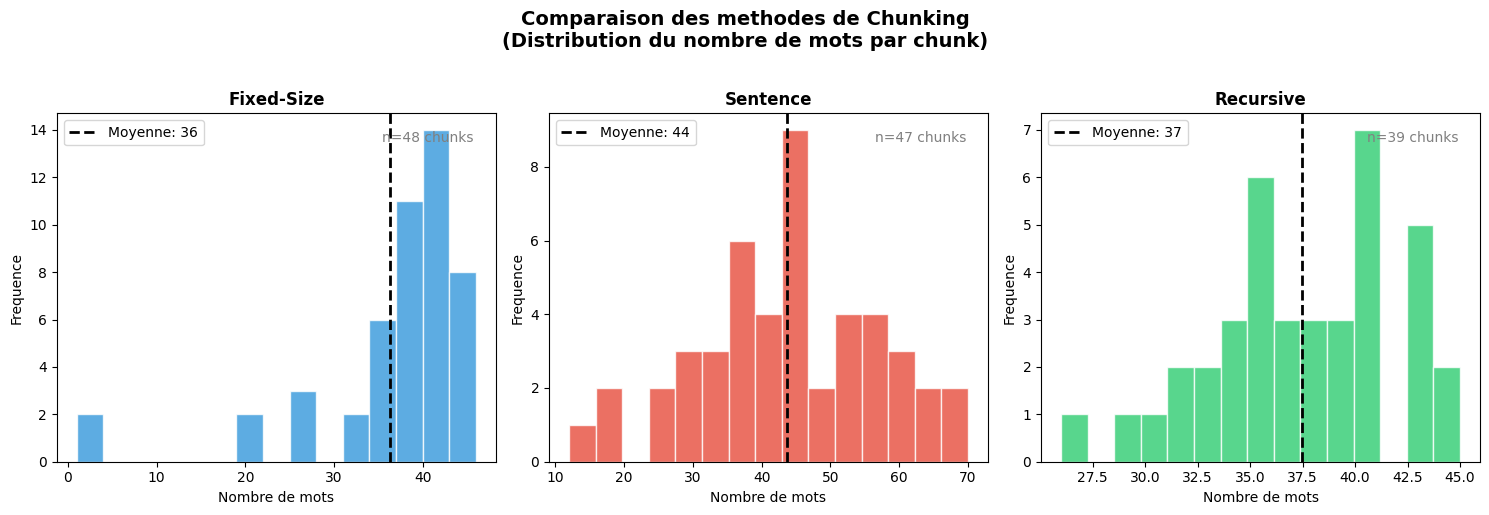


TABLEAU RECAPITULATIF
Methode          Nb Chunks    Moy. mots   Std mots
-------------------------------------------------------
Fixed-Size              48         36.4        9.3
Sentence                47         43.6       13.1
Recursive               39         37.5        4.3


In [6]:
import matplotlib.pyplot as plt        # tracer les graphiques
import matplotlib.patches as mpatches  # (non utilise directement, garde pour compatibilite legendes)

# ============================================================
# VISUALISATION : Comparaison des tailles de chunks
# selon les differentes methodes
# ============================================================

# Dictionnaire qui va accumuler, pour chaque methode, la liste des tailles (en mots) de chaque chunk
tous_chunks = {'Fixed-Size': [], 'Sentence': [], 'Recursive': []}

for _, row in df.iterrows():           # parcourir chaque document du corpus
    texte = row['texte']

    # Methode 1 : Fixed-size -> on ne garde que le nombre de mots de chaque chunk
    for c in fixed_size_chunking(texte, taille_chunk=300, overlap=50):
        tous_chunks['Fixed-Size'].append(len(c['texte'].split()))

    # Methode 2 : Sentence
    for c in sentence_chunking(texte, phrases_par_chunk=3):
        tous_chunks['Sentence'].append(c['nb_mots'])

    # Methode 3 : Recursive
    for c in recursive_chunking(texte, taille_max=350, overlap=50):
        tous_chunks['Recursive'].append(c['nb_mots'])

# Creer une figure avec 3 sous-graphiques (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison des methodes de Chunking\n(Distribution du nombre de mots par chunk)',
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#3498db', '#e74c3c', '#2ecc71']   # une couleur par methode

# zip(axes, ..., colors) associe chaque sous-graphique a une methode et une couleur
for ax, (methode, tailles), color in zip(axes, tous_chunks.items(), colors):
    ax.hist(tailles, bins=15, color=color, alpha=0.8, edgecolor='white')  # histogramme des tailles
    ax.set_title(f'{methode}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Frequence')

    # Ligne verticale a la moyenne + legende
    mean_val = np.mean(tailles)
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.0f}')
    ax.legend()
    ax.text(0.95, 0.95, f'n={len(tailles)} chunks', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('chunking_comparison.png', bbox_inches='tight', dpi=150)  # sauvegarde de la figure en PNG
plt.show()                                                              # affichage dans le notebook

# Tableau recapitulatif texte des statistiques par methode
print('\nTABLEAU RECAPITULATIF')
print('=' * 55)
print(f'{"Methode":<15} {"Nb Chunks":>10} {"Moy. mots":>12} {"Std mots":>10}')
print('-' * 55)
for methode, tailles in tous_chunks.items():
    print(f'{methode:<15} {len(tailles):>10} {np.mean(tailles):>12.1f} {np.std(tailles):>10.1f}')


### 3.5 Application du chunking à tout le corpus

In [7]:
# ============================================================
# APPLICATION : Chunker tous les documents avec la methode
# Recursive (la plus adaptee pour un RAG de qualite)
# On garde les metadonnees (doc_id, titre, categorie)
# pour pouvoir les retrouver lors de la recherche
# ============================================================

all_chunks = []  # liste finale de tous les chunks (de tous les documents) avec metadonnees

for _, row in df.iterrows():                       # parcourir chaque document du DataFrame
    # Creer les chunks pour ce document avec le chunking recursif
    chunks = recursive_chunking(row['texte'], taille_max=400, overlap=60)

    for j, chunk in enumerate(chunks):              # j = position du chunk dans le document
        # Enrichir chaque chunk avec les metadonnees du document parent
        chunk_enrichi = {
            'chunk_id': f"{row['id']}_chunk_{j:02d}",   # identifiant unique du chunk (doc + index)
            'doc_id': row['id'],                         # id du document parent
            'titre': row['titre'],                       # titre du document parent
            'categorie': row['categorie'],               # categorie du document parent
            'chunk_index': j,                            # position du chunk dans le document
            'texte': chunk['texte'],                     # texte du chunk
            'nb_mots': chunk['nb_mots'],
            'nb_caracteres': chunk['nb_caracteres']
        }
        all_chunks.append(chunk_enrichi)

# Convertir la liste de chunks en DataFrame (plus pratique pour la suite)
df_chunks = pd.DataFrame(all_chunks)

print(f'Corpus chunke : {len(df)} documents -> {len(df_chunks)} chunks')
print(f'\nApercu des chunks :')
print(df_chunks[['chunk_id', 'titre', 'nb_mots']].head(10).to_string(index=False))

print(f'\nDistribution des chunks par document :')
print(df_chunks.groupby('titre')['chunk_id'].count().to_string())


Corpus chunke : 8 documents -> 39 chunks

Apercu des chunks :
        chunk_id                                       titre  nb_mots
doc_001_chunk_00            Introduction au Machine Learning       37
doc_001_chunk_01            Introduction au Machine Learning       40
doc_001_chunk_02            Introduction au Machine Learning       41
doc_001_chunk_03            Introduction au Machine Learning       43
doc_002_chunk_00 Les Reseaux de Neurones et le Deep Learning       38
doc_002_chunk_01 Les Reseaux de Neurones et le Deep Learning       45
doc_002_chunk_02 Les Reseaux de Neurones et le Deep Learning       43
doc_002_chunk_03 Les Reseaux de Neurones et le Deep Learning       37
doc_002_chunk_04 Les Reseaux de Neurones et le Deep Learning       36
doc_003_chunk_00       L'Architecture Transformer et les LLM       43

Distribution des chunks par document :
titre
Computer Vision et Traitement d'Images           5
Ethique et Biais en Intelligence Artificielle    5
Introduction au Mach

---
## 4. 🔢 Les Embeddings

### Qu'est-ce qu'un embedding ?

Un **embedding** est une représentation numérique (vecteur) d'un texte dans un espace de haute dimension.
L'objectif : **les textes sémantiquement similaires doivent avoir des vecteurs proches**.

```
Texte → Modèle d'Embedding → Vecteur [0.23, -0.45, 0.87, ..., 0.12]  (768 dimensions)

"Le chien aboie"     → [0.23, -0.45, 0.87, ...]
"Le chien crie"      → [0.21, -0.43, 0.89, ...]  ← proche !
"La table est ronde" → [-0.65, 0.12, -0.34, ...] ← loin !
```

### Types d'embeddings :
| Méthode | Année | Dimensions | Points forts |
|---------|-------|-----------|-------------|
| TF-IDF | 1972 | Variable | Simple, interprétable, rapide |
| Word2Vec | 2013 | 100-300 | Capture relations sémantiques |
| GloVe | 2014 | 50-300 | Entraîné sur statistiques globales |
| FastText | 2016 | 100-300 | Gère les mots inconnus |
| BERT | 2018 | 768 | Bidirectionnel, contextuel |
| Sentence-BERT | 2019 | 384-768 | **Optimal pour le RAG** |
| OpenAI Ada-002 | 2022 | 1536 | Très performant, payant |

### 4.1 TF-IDF (Term Frequency - Inverse Document Frequency)

In [8]:
import warnings
from collections import Counter        # comptage efficace d'occurrences (termes, tokens...)
warnings.filterwarnings('ignore')       # masque les avertissements non bloquants

# ============================================================
# METHODE 1 : TF-IDF (implementation maison, sans scikit-learn)
#
# TF (Term Frequency) = nombre de fois qu'un mot apparait / total mots
# IDF (Inverse Doc Frequency) = log(total docs / docs contenant le mot)
# TF-IDF = TF x IDF -> penalise les mots tres communs (le, la, de, ...)
#
# Avantages : pas de pre-entrainement, tres rapide, interpretable
# Inconvenients : pas de sens semantique (chat != felin), sparse
#
# NOTE (corrige un bug d'environnement) : la version originale utilisait
# sklearn.feature_extraction.text.TfidfVectorizer et
# sklearn.metrics.pairwise.cosine_similarity. Sur cette machine, scikit-learn
# ne peut pas s'importer (sa dependance scipy est bloquee par une politique
# systeme). On reimplemente donc TF-IDF et la similarite cosinus en numpy pur,
# dans le meme esprit "from scratch" que SimpleVectorDB plus bas.
# ============================================================

class VectoriseurTFIDF:
    """
    Reimplementation minimale de TfidfVectorizer (scikit-learn) en numpy pur.
    Supporte : max_features, ngram_range, min_df, sublinear_tf, normalisation L2.
    """

    def __init__(self, max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True):
        self.max_features = max_features    # nombre maximum de colonnes (termes) gardees
        self.ngram_range = ngram_range       # (n_min, n_max) : unigrammes, bigrammes, ...
        self.min_df = min_df                 # frequence documentaire minimale pour garder un terme
        self.sublinear_tf = sublinear_tf     # si True : TF = 1 + log(tf) au lieu de tf brut
        self.vocabulaire_ = {}               # terme -> indice de colonne dans la matrice
        self.idf_ = None                     # vecteur des IDF, aligne sur vocabulaire_

    def _tokeniser(self, texte):
        """Transforme un texte en liste de tokens (mots + n-grammes)."""
        # Extrait les suites de lettres/chiffres (accents inclus), en minuscules
        mots = re.findall(r"[a-zà-öø-ÿ0-9]+", texte.lower())

        tokens = []
        n_min, n_max = self.ngram_range
        for n in range(n_min, n_max + 1):                 # pour chaque taille de n-gramme demandee
            for i in range(len(mots) - n + 1):             # glisser une fenetre de taille n sur les mots
                tokens.append('_'.join(mots[i:i + n]))     # ex: bigramme "deep_learning"
        return tokens

    def fit(self, corpus):
        """Apprend le vocabulaire et les IDF a partir d'une liste de textes."""
        docs_tokens = [self._tokeniser(t) for t in corpus]   # tokenise chaque document une seule fois

        # Frequence documentaire (df) : dans combien de documents chaque terme apparait
        df_terme = Counter()
        for tokens in docs_tokens:
            for terme in set(tokens):                          # set() : compter 1 fois par document
                df_terme[terme] += 1

        n_docs = len(corpus)

        # Ne garder que les termes presents dans au moins min_df documents
        termes_valides = [t for t, df in df_terme.items() if df >= self.min_df]

        # Garder les max_features termes les plus frequents (heuristique proche de sklearn)
        termes_valides.sort(key=lambda t: df_terme[t], reverse=True)
        termes_valides = termes_valides[:self.max_features]
        termes_valides.sort()                                   # ordre alphabetique -> colonnes stables

        # Construire le vocabulaire final : terme -> indice de colonne
        self.vocabulaire_ = {t: i for i, t in enumerate(termes_valides)}

        # Calcul de l'IDF lisse (meme formule que scikit-learn par defaut) :
        # idf(t) = ln( (1 + n_docs) / (1 + df(t)) ) + 1
        self.idf_ = np.zeros(len(self.vocabulaire_))
        for t, i in self.vocabulaire_.items():
            self.idf_[i] = np.log((1 + n_docs) / (1 + df_terme[t])) + 1

        return self

    def transform(self, corpus):
        """Transforme une liste de textes en matrice TF-IDF (n_docs x n_termes)."""
        n_docs = len(corpus)
        n_termes = len(self.vocabulaire_)
        matrice = np.zeros((n_docs, n_termes), dtype=np.float64)   # matrice dense (corpus petit)

        for i, texte in enumerate(corpus):              # pour chaque document a transformer
            tokens = self._tokeniser(texte)
            if not tokens:
                continue
            compte = Counter(tokens)                      # occurrences de chaque token dans ce document
            for terme, tf in compte.items():
                j = self.vocabulaire_.get(terme)
                if j is None:                              # terme absent du vocabulaire -> ignore
                    continue
                tf_val = (1 + np.log(tf)) if self.sublinear_tf else tf
                matrice[i, j] = tf_val * self.idf_[j]       # TF-IDF = TF pondere x IDF

        # Normalisation L2 par ligne (comme sklearn, norm='l2' par defaut)
        normes = np.linalg.norm(matrice, axis=1, keepdims=True)
        normes[normes == 0] = 1.0                          # evite la division par zero
        matrice = matrice / normes
        return matrice

    def fit_transform(self, corpus):
        """Enchaine fit() puis transform() sur le meme corpus."""
        return self.fit(corpus).transform(corpus)


def similarite_cosinus(A, B=None):
    """
    Matrice de similarite cosinus entre les lignes de A et les lignes de B.
    Si B est None, calcule la similarite de A avec elle-meme.
    cos(A_i, B_j) = (A_i . B_j) / (||A_i|| * ||B_j||)
    """
    if B is None:
        B = A
    A_norm = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-10)  # normaliser chaque ligne de A
    B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-10)  # normaliser chaque ligne de B
    return A_norm @ B_norm.T                                          # produit scalaire = cosinus


# Extraire tous les textes des chunks (liste de strings)
textes_chunks = df_chunks['texte'].tolist()

# Creer et entrainer le vectoriseur TF-IDF maison
tfidf_vectorizer = VectoriseurTFIDF(
    max_features=5000,
    ngram_range=(1, 2),     # inclut les bigrammes (paires de mots)
    min_df=2,               # ignore les termes presents dans moins de 2 documents
    sublinear_tf=True       # applique log sur TF pour reduire l'impact des repetitions
)

# Entrainer le vectoriseur ET transformer tous les chunks en une seule passe
tfidf_matrix = tfidf_vectorizer.fit_transform(textes_chunks)

print(f'Matrice TF-IDF : {tfidf_matrix.shape}')
print(f'   -> {tfidf_matrix.shape[0]} chunks x {tfidf_matrix.shape[1]} features')
densite = (tfidf_matrix != 0).sum() / tfidf_matrix.size
print(f'   -> Densite : {densite:.4f} (proportion de valeurs non nulles)')


def recherche_tfidf(requete, top_k=3):
    """
    Recherche les chunks les plus similaires a une requete.
    Similarite cosinus : mesure l'angle entre 2 vecteurs (0=opposes, 1=identiques)
    """
    # Transformer la requete avec le MEME vectoriseur (memes colonnes/vocabulaire)
    vecteur_requete = tfidf_vectorizer.transform([requete])

    # Calculer la similarite cosinus entre la requete et tous les chunks
    scores = similarite_cosinus(vecteur_requete, tfidf_matrix).flatten()

    # Trier les indices par score decroissant et garder les top_k
    indices_tries = np.argsort(scores)[::-1][:top_k]

    return [(df_chunks.iloc[i]['texte'], scores[i], df_chunks.iloc[i]['titre'])
            for i in indices_tries]


# ---- Test de recherche ----
requete = "comment les reseaux de neurones apprennent-ils ?"
resultats = recherche_tfidf(requete)

print(f'\nRequete : "{requete}"')
print('=' * 60)
for i, (texte, score, titre) in enumerate(resultats):
    print(f'\nResultat {i+1} (score: {score:.4f}) -- {titre}')
    print(f'   {texte[:200]}...')


Matrice TF-IDF : (39, 310)
   -> 39 chunks x 310 features
   -> Densite : 0.0922 (proportion de valeurs non nulles)

Requete : "comment les reseaux de neurones apprennent-ils ?"

Resultat 1 (score: 0.4992) -- Les Reseaux de Neurones et le Deep Learning
   Les reseaux de neurones artificiels s'inspirent du fonctionnement du cerveau humain.
        Ils sont composes de couches de neurones artificiels connectes entre eux par des poids.
        Le deep lea...

Resultat 2 (score: 0.2430) -- Les Reseaux de Neurones et le Deep Learning
   Un reseau de neurones basique comprend trois types de couches :
        La couche d'entree recoit les donnees brutes (pixels d'une image, mots d'une phrase).
        Les couches cachees transforment p...

Resultat 3 (score: 0.2138) -- Reinforcement Learning et Agents Intelligents
   Q-Learning est l'algorithme fondamental du RL. Il apprend une fonction Q(s,a)
        qui estime la valeur attendue de chaque action dans chaque etat.
        DQN (Deep Q-Network

### 4.2 Sentence Transformers (état de l'art)

In [9]:
import time  # mesure du temps de generation des embeddings

# ============================================================
# METHODE 2 : Sentence Transformers (SBERT)
#
# Base sur BERT, fine-tune pour generer des embeddings de phrases
# Utilise du mean-pooling sur les tokens pour obtenir 1 vecteur par phrase
#
# Modele 'paraphrase-multilingual-MiniLM-L12-v2' :
# - multilingue (supporte le francais)
# - 384 dimensions
#
# Avantages : capture le sens semantique profond, dense vectors
# Inconvenients : necessite GPU pour la production, plus lent que TF-IDF
#
# NOTE (corrige un bug d'environnement) : charger un vrai modele SBERT
# necessite (1) que la bibliotheque sentence-transformers s'importe (elle
# depend en interne de scikit-learn -> peut etre bloquee comme en section 4.1)
# et (2) un acces reseau au Hugging Face Hub pour telecharger les poids du
# modele. Les deux peuvent echouer selon la machine/le reseau.
#
# `charger_modele_embedding` essaie d'abord le vrai modele SBERT ; s'il
# n'est pas disponible, elle bascule automatiquement sur un embedding
# "maison" (TF-IDF + PCA, tous deux definis en numpy pur ci-dessus/ci-dessous)
# qui expose la MEME API (.encode(...), .get_sentence_embedding_dimension()).
# Toute la suite du notebook fonctionne donc a l'identique dans les deux cas.
# ============================================================

def pca_manuelle(X, n_composantes=2):
    """
    ACP (PCA) maison via SVD (remplace sklearn.decomposition.PCA).
    X : matrice (n_echantillons x n_features)
    Retourne (X_reduit, composantes) ou X_reduit a n_composantes colonnes.
    """
    X_centre = X - X.mean(axis=0, keepdims=True)             # centrer les donnees (moyenne nulle)
    U, S, Vt = np.linalg.svd(X_centre, full_matrices=False)  # decomposition en valeurs singulieres
    composantes = Vt[:n_composantes]                          # axes principaux (n_composantes x n_features)
    X_reduit = X_centre @ composantes.T                       # projection des donnees sur ces axes
    return X_reduit, composantes


class EmbeddingTFIDFSecours:
    """
    Embedding de secours 100% numpy (TF-IDF maison + PCA maison), utilise
    uniquement si le vrai modele SBERT est indisponible sur cette machine.
    Expose la meme API que sentence_transformers.SentenceTransformer :
    .encode(textes, ...) et .get_sentence_embedding_dimension().
    """

    def __init__(self, corpus, dimension=128):
        # Vectoriseur TF-IDF entraine une fois sur le corpus de reference (les chunks)
        self.vectoriseur = VectoriseurTFIDF(max_features=5000, ngram_range=(1, 2), min_df=1)
        matrice_tfidf = self.vectoriseur.fit_transform(corpus)

        # Dimension finale = plus petite valeur raisonnable (pas plus que le nb d'echantillons/features)
        self.dimension = max(2, min(dimension, matrice_tfidf.shape[0] - 1, matrice_tfidf.shape[1]))

        # PCA appris une fois sur le corpus de reference (moyenne + axes principaux)
        self.moyenne = matrice_tfidf.mean(axis=0, keepdims=True)
        _, self.composantes = pca_manuelle(matrice_tfidf, n_composantes=self.dimension)

    def get_sentence_embedding_dimension(self):
        return self.dimension

    def encode(self, textes, normalize_embeddings=True, batch_size=None, show_progress_bar=False):
        """Encode une liste de textes (ou un seul texte) en vecteurs denses."""
        if isinstance(textes, str):
            textes = [textes]

        tfidf = self.vectoriseur.transform(textes)               # TF-IDF avec le vocabulaire deja appris
        reduit = (tfidf - self.moyenne) @ self.composantes.T      # projection sur les axes PCA appris

        if normalize_embeddings:
            normes = np.linalg.norm(reduit, axis=1, keepdims=True)
            normes[normes == 0] = 1.0
            reduit = reduit / normes

        return reduit


def charger_modele_embedding(nom_modele, corpus_secours):
    """
    Essaie de charger un vrai modele SBERT. En cas d'echec (bibliotheque
    bloquee, pas de reseau, ...), replie sur l'embedding TF-IDF+PCA maison.
    """
    try:
        from sentence_transformers import SentenceTransformer
        modele = SentenceTransformer(nom_modele)
        print(f'Modele SBERT charge : {nom_modele}')
        return modele
    except Exception as e:
        print(f'SBERT indisponible ({type(e).__name__}: {str(e)[:100]})')
        print('-> repli automatique sur l\'embedding TF-IDF + PCA maison.')
        return EmbeddingTFIDFSecours(corpus_secours)


print('Chargement du modele d\'embedding...')

# Charge un modele multilingue (supporte le francais), ou le repli maison si indisponible
modele_embedding = charger_modele_embedding(
    'paraphrase-multilingual-MiniLM-L12-v2',
    corpus_secours=textes_chunks
)

print(f'   Dimension des embeddings : {modele_embedding.get_sentence_embedding_dimension()}')

# ============================================================
# Generer les embeddings pour tous les chunks
# batch_size=32 : traiter 32 chunks a la fois (optimisation memoire)
# show_progress_bar : afficher une barre de progression
# ============================================================

print('\nGeneration des embeddings pour tous les chunks...')
debut = time.time()

embeddings = modele_embedding.encode(
    textes_chunks,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True  # normaliser pour utiliser le produit scalaire comme similarite
)
embeddings = np.asarray(embeddings)   # garantit un ndarray numpy (utile pour le repli maison)

duree = time.time() - debut
print(f'\nEmbeddings generes !')
print(f'   Shape : {embeddings.shape}  ({embeddings.shape[0]} chunks x {embeddings.shape[1]} dimensions)')
print(f'   Temps : {duree:.2f}s ({duree/len(textes_chunks)*1000:.1f}ms par chunk)')
print(f'   Taille memoire : {embeddings.nbytes / 1024:.1f} KB')


Chargement du modele d'embedding...


SBERT indisponible (ImportError: DLL load failed while importing _distance_pybind: Une stratégie de contrôle d’application a bloqué c)
-> repli automatique sur l'embedding TF-IDF + PCA maison.
   Dimension des embeddings : 38

Generation des embeddings pour tous les chunks...

Embeddings generes !
   Shape : (39, 38)  (39 chunks x 38 dimensions)
   Temps : 0.02s (0.5ms par chunk)
   Taille memoire : 11.6 KB


### 4.3 Visualisation des Embeddings

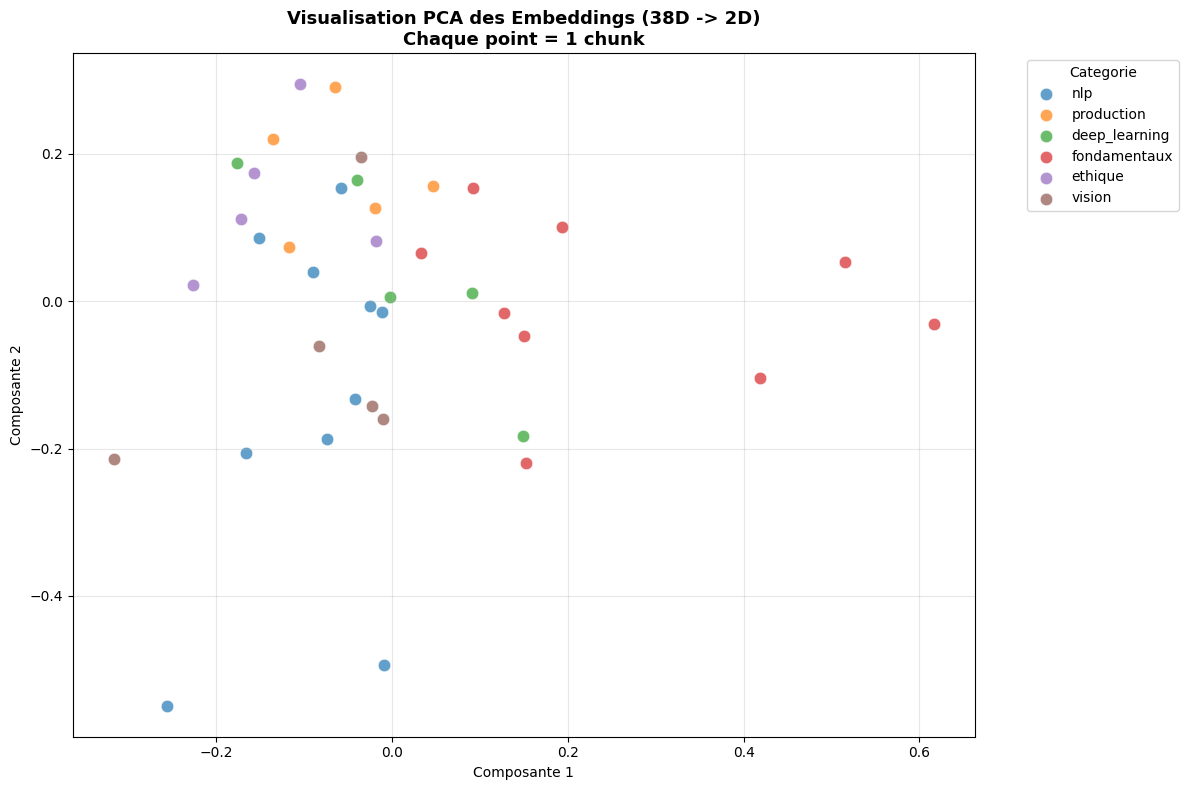

Observation : les chunks de meme categorie devraient etre regroupes !
   C'est la preuve que les embeddings capturent le sens semantique.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============================================================
# VISUALISATION : Reduire les embeddings de haute dimension a 2D
# pour les visualiser sur un plan
#
# NOTE (corrige un bug d'environnement) : la version originale enchainait
# sklearn.decomposition.PCA puis sklearn.manifold.TSNE. scikit-learn n'est
# pas utilisable sur cette machine (voir section 4.1) : on reduit donc les
# embeddings directement a 2D avec la fonction pca_manuelle() (definie en
# section 4.2, methode ACP/PCA "from scratch" par SVD). t-SNE n'a pas
# d'equivalent simple a reimplementer sans scipy : sur un aussi petit
# corpus (quelques dizaines de chunks), une PCA en 2D suffit largement
# a observer les regroupements par categorie.
# ============================================================

# Reduction directe des embeddings (Nd) vers 2D par PCA maison
embeddings_2d, _ = pca_manuelle(embeddings, n_composantes=2)

# Creer la figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Couleurs par categorie de document
categories = df_chunks['categorie'].tolist()               # categorie de chaque chunk, dans l'ordre
categories_uniques = list(set(categories))                  # categories distinctes
palette = plt.cm.tab10.colors                                # palette de 10 couleurs
couleur_map = {cat: palette[i] for i, cat in enumerate(categories_uniques)}  # categorie -> couleur

# Tracer chaque categorie separement (pour avoir une legende propre)
for cat in categories_uniques:
    indices = [i for i, c in enumerate(categories) if c == cat]   # indices des chunks de cette categorie
    x = embeddings_2d[indices, 0]
    y = embeddings_2d[indices, 1]
    ax.scatter(x, y, c=[couleur_map[cat]], label=cat, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

ax.set_title(f'Visualisation PCA des Embeddings ({embeddings.shape[1]}D -> 2D)\nChaque point = 1 chunk',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Composante 1')
ax.set_ylabel('Composante 2')
ax.legend(title='Categorie', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('embeddings_pca.png', bbox_inches='tight', dpi=150)
plt.show()

print('Observation : les chunks de meme categorie devraient etre regroupes !')
print('   C\'est la preuve que les embeddings capturent le sens semantique.')


### 4.4 Mesures de Similarité

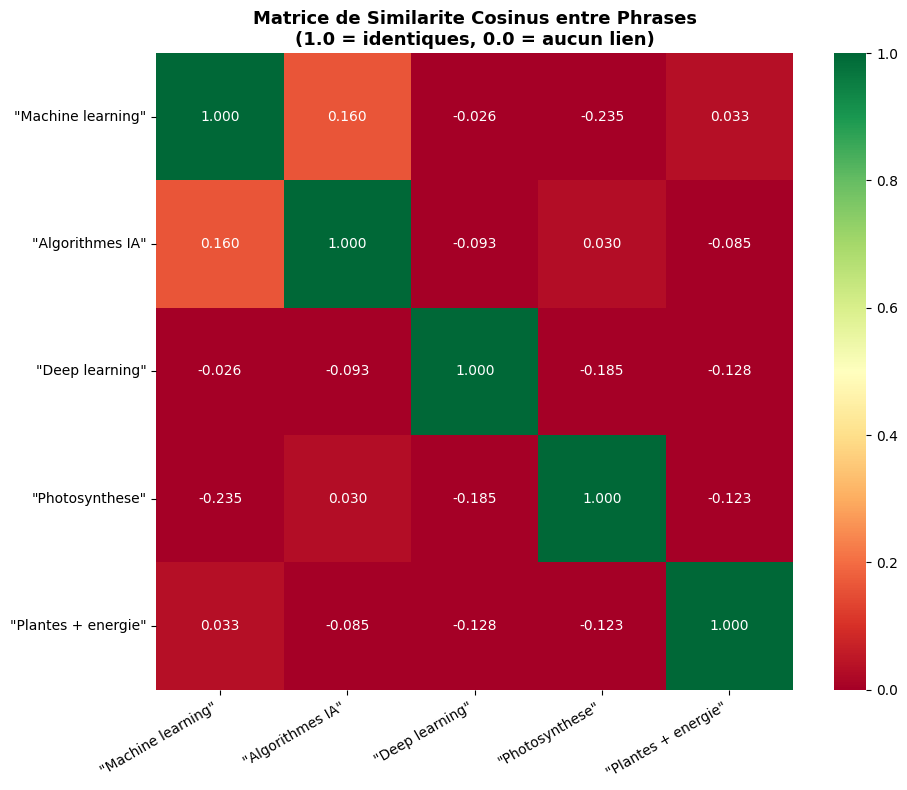

Observation attendue :
   - Les 3 phrases sur l'IA devraient avoir une haute similarite entre elles
   - Les 2 phrases sur les plantes devraient etre similaires entre elles
   - IA <-> Plantes devrait avoir une faible similarite


In [11]:
import seaborn as sns  # heatmap plus lisible que matplotlib brut

# ============================================================
# LES 3 MESURES DE SIMILARITE POUR LES VECTEURS
#
# 1. Similarite Cosinus : mesure l'angle entre 2 vecteurs
#    cos(t) = (A.B) / (|A| x |B|)
#    Valeur entre -1 et 1 (1 = identiques, 0 = orthogonaux)
#    -> Recommande pour les embeddings texte !
#
# 2. Distance Euclidienne : distance en ligne droite
#    d = racine(somme((ai - bi)^2))
#    Plus petite = plus similaire
#    -> Bien si embeddings normalises (equivalent au cosinus)
#
# 3. Produit Scalaire (Dot Product) : A.B = somme(ai x bi)
#    -> Equivalent au cosinus si vecteurs normalises
#    -> Tres rapide a calculer (FAISS l'utilise)
#
# NOTE : cosine_similarity(sklearn) est remplacee par la fonction maison
# similarite_cosinus(), definie en section 4.1.
# ============================================================

# Phrases exemples pour la demonstration
phrases_demo = [
    "Le machine learning permet aux machines d'apprendre",
    "Les algorithmes d'IA apprennent a partir des donnees",
    "Le deep learning utilise des reseaux de neurones profonds",
    "La photosynthese est un processus biologique",
    "Les plantes utilisent la lumiere solaire pour produire de l'energie"
]

# Generer les embeddings de ces phrases avec le modele charge en section 4.2
emb_demo = np.asarray(modele_embedding.encode(phrases_demo, normalize_embeddings=True))

# Calculer la matrice de similarite cosinus (5x5) entre ces phrases
sim_matrix = similarite_cosinus(emb_demo)

# Visualiser sous forme de heatmap
fig, ax = plt.subplots(figsize=(10, 8))

labels_courts = [
    '"Machine learning"',
    '"Algorithmes IA"',
    '"Deep learning"',
    '"Photosynthese"',
    '"Plantes + energie"'
]

sns.heatmap(
    sim_matrix,
    xticklabels=labels_courts,
    yticklabels=labels_courts,
    annot=True,                 # afficher les valeurs numeriques dans chaque case
    fmt='.3f',
    cmap='RdYlGn',               # rouge (faible) -> vert (fort)
    vmin=0, vmax=1,
    ax=ax,
    square=True
)

ax.set_title('Matrice de Similarite Cosinus entre Phrases\n(1.0 = identiques, 0.0 = aucun lien)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('similarity_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print('Observation attendue :')
print('   - Les 3 phrases sur l\'IA devraient avoir une haute similarite entre elles')
print('   - Les 2 phrases sur les plantes devraient etre similaires entre elles')
print('   - IA <-> Plantes devrait avoir une faible similarite')


---
## 5. 🗄️ Base de Données Vectorielle

Une **base de données vectorielle** stocke les embeddings et permet une **recherche ultra-rapide** par similarité.

### Comparaison des solutions :

| Solution | Type | Avantages | Usage |
|----------|------|-----------|-------|
| Notre implémentation | From scratch | Pédagogique | Apprentissage |
| FAISS | Bibliothèque | Ultra-rapide, scalable | Production (millions de vecteurs) |
| ChromaDB | Base de données | Simple, persistant, filtres | Projets RAG |
| Pinecone | Cloud | Managé, haute dispo | Production SaaS |
| Weaviate | Base de données | GraphQL, hybride | Enterprise |
| Qdrant | Base de données | Rust, rapide, filtres | Production moderne |


### 5.1 VectorDB From Scratch

In [12]:
# ============================================================
# IMPLEMENTATION FROM SCRATCH : VectorDB minimale
# Pour comprendre le fonctionnement interne
# ============================================================

class SimpleVectorDB:
    """
    Base de donnees vectorielle simple implementee from scratch.
    Utilise une recherche par force brute (calcul de similarite
    avec tous les vecteurs stockes).

    Complexite : O(n) par requete (n = nombre de vecteurs)
    OK pour < 10 000 vecteurs, trop lent au-dela.
    """

    def __init__(self):
        """Initialiser les structures de donnees internes."""
        self.vecteurs = []       # liste des embeddings numpy stockes
        self.metadonnees = []    # liste des metadonnees associees (meme index que vecteurs)
        self.dimension = None    # dimension attendue des vecteurs (verification de coherence)

    def ajouter(self, vecteur, metadata):
        """
        Ajouter un vecteur avec ses metadonnees.
        vecteur  : numpy array de dimension D
        metadata : dict avec les infos (texte, doc_id, titre, etc.)
        """
        # Verifier que la dimension est coherente avec les vecteurs deja stockes
        if self.dimension is None:
            self.dimension = len(vecteur)                     # premier vecteur -> fixe la dimension
        elif len(vecteur) != self.dimension:
            raise ValueError(f'Dimension attendue : {self.dimension}, recue : {len(vecteur)}')

        # Normaliser le vecteur (pour que le produit scalaire = cosinus)
        norme = np.linalg.norm(vecteur)
        vecteur_normalise = vecteur / (norme + 1e-10)         # 1e-10 evite la division par zero

        self.vecteurs.append(vecteur_normalise)
        self.metadonnees.append(metadata)

    def ajouter_batch(self, vecteurs, metadonnees_list):
        """Ajouter plusieurs vecteurs en une fois (plus pratique que d'appeler ajouter() en boucle)."""
        for vecteur, meta in zip(vecteurs, metadonnees_list):
            self.ajouter(vecteur, meta)
        print(f'{len(vecteurs)} vecteurs ajoutes. Total : {len(self.vecteurs)}')

    def rechercher(self, vecteur_requete, top_k=5, seuil_min=0.0):
        """
        Rechercher les top_k vecteurs les plus similaires a vecteur_requete.

        Algorithme :
        1. Normaliser le vecteur requete
        2. Calculer le produit scalaire avec TOUS les vecteurs stockes (= cosinus)
        3. Trier par score decroissant
        4. Retourner les top_k avec leurs metadonnees
        """
        if not self.vecteurs:                # base vide -> rien a retourner
            return []

        # Normaliser la requete de la meme facon que les vecteurs stockes
        norme = np.linalg.norm(vecteur_requete)
        requete_normalisee = vecteur_requete / (norme + 1e-10)

        # Convertir la liste de vecteurs en matrice numpy (pour vectoriser le calcul)
        matrice = np.array(self.vecteurs)     # shape : (n_vecteurs, dimension)

        # Produit scalaire = similarite cosinus (car tous les vecteurs sont normalises)
        # matrice @ requete : calcul matriciel -> resultat en une seule operation !
        scores = matrice @ requete_normalisee   # shape : (n_vecteurs,)

        # Trier les indices par score decroissant
        indices_tries = np.argsort(scores)[::-1]

        # Filtrer par seuil minimal et garder les top_k premiers
        resultats = []
        for idx in indices_tries:
            if len(resultats) >= top_k:
                break
            if scores[idx] >= seuil_min:
                resultats.append({
                    'score': float(scores[idx]),
                    'metadata': self.metadonnees[idx]
                })

        return resultats

    def __len__(self):
        """Permet d'utiliser len(db_scratch) pour connaitre le nombre de vecteurs stockes."""
        return len(self.vecteurs)

    def __repr__(self):
        """Representation textuelle utilisee par print(db_scratch)."""
        return f'SimpleVectorDB({len(self.vecteurs)} vecteurs, dim={self.dimension})'


# ---- Creer la base et y inserer tous nos chunks ----
db_scratch = SimpleVectorDB()

# Preparer les metadonnees : chaque ligne du DataFrame devient un dictionnaire
metadonnees_list = df_chunks.to_dict('records')

# Inserer tous les embeddings (deja calcules en section 4.2) dans la base
db_scratch.ajouter_batch(embeddings, metadonnees_list)
print(db_scratch)


39 vecteurs ajoutes. Total : 39
SimpleVectorDB(39 vecteurs, dim=38)


### 5.2 FAISS — Facebook AI Similarity Search

In [13]:
import faiss  # bibliotheque de recherche vectorielle ultra-optimisee (Meta/Facebook)

# ============================================================
# FAISS : Bibliotheque ultra-optimisee pour la recherche de vecteurs
# Developpee par Facebook/Meta Research
#
# PRINCIPAUX INDEX FAISS :
#
# IndexFlatL2      : distance L2 exacte, force brute
#                    -> Precision parfaite, lent sur gros volumes
#
# IndexFlatIP      : produit scalaire exact (Inner Product)
#                    -> Utilise avec vecteurs normalises = cosinus
#
# IndexIVFFlat     : Inverted File Index
#                    -> Divise l'espace en clusters (k-means)
#                    -> Recherche seulement dans les clusters proches
#                    -> 10-100x plus rapide, legerement moins precis
#
# IndexHNSW        : Hierarchical Navigable Small World
#                    -> Graphe de navigation hierarchique
#                    -> Tres rapide en requete, bonne precision
#
# IndexIVFPQ       : IVF + Product Quantization (compression)
#                    -> Vecteurs compresses, tres leger en memoire
# ============================================================

# Dimension des embeddings (nombre de colonnes de la matrice)
dimension = embeddings.shape[1]

# FAISS exige des vecteurs en float32 (pas float64) -> conversion explicite
embeddings_f32 = embeddings.astype(np.float32)

# ---- INDEX 1 : Flat L2 (exact, force brute, distance euclidienne) ----
index_flat = faiss.IndexFlatL2(dimension)
index_flat.add(embeddings_f32)
print(f'Index FlatL2 cree : {index_flat.ntotal} vecteurs')

# ---- INDEX 2 : Flat IP (produit scalaire = cosinus pour vecteurs normalises) ----
index_ip = faiss.IndexFlatIP(dimension)
index_ip.add(embeddings_f32)
print(f'Index FlatIP cree : {index_ip.ntotal} vecteurs')

# ---- INDEX 3 : IVF (approche, plus rapide sur gros volumes) ----
# nlist = nombre de clusters (racine carree de n est une bonne heuristique)
nlist = max(4, int(np.sqrt(len(embeddings_f32))))
quantizer = faiss.IndexFlatL2(dimension)              # "quantizer" utilise pour le k-means interne
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist)

# IMPORTANT : il faut entrainer l'index IVF avant d'ajouter des vecteurs
# (cette etape cree les clusters par k-means)
index_ivf.train(embeddings_f32)
index_ivf.add(embeddings_f32)
index_ivf.nprobe = 3    # nombre de clusters explores lors d'une recherche (precision/vitesse)
print(f'Index IVF cree : {index_ivf.ntotal} vecteurs, {nlist} clusters')


def recherche_faiss(index, requete_embedding, top_k=3, index_name=""):
    """
    Effectue une recherche avec un index FAISS et affiche les resultats.
    Retourne les top_k vecteurs les plus proches de requete_embedding.
    """
    # FAISS attend un tableau 2D : (1, dimension) meme pour une seule requete
    requete = requete_embedding.reshape(1, -1).astype(np.float32)

    debut = time.time()
    # distances : scores de similarite (L2 pour Flat/IVF-L2, produit scalaire pour FlatIP)
    # indices   : indices des vecteurs trouves dans notre matrice d'origine
    distances, indices = index.search(requete, top_k)
    duree = (time.time() - debut) * 1000        # conversion en millisecondes

    print(f'\n{index_name} : {duree:.3f}ms')
    for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        chunk = df_chunks.iloc[idx]
        print(f'  {i+1}. [score={dist:.4f}] {chunk["titre"]} | {chunk["texte"][:80]}...')


# ---- Test de recherche ----
requete_test = "comment fonctionne l'attention dans les transformers ?"
emb_requete = np.asarray(modele_embedding.encode([requete_test], normalize_embeddings=True))[0]

print(f'Requete : "{requete_test}"')
print('=' * 70)

recherche_faiss(index_flat, emb_requete, top_k=3, index_name="IndexFlatL2")
recherche_faiss(index_ip, emb_requete, top_k=3, index_name="IndexFlatIP")
recherche_faiss(index_ivf, emb_requete, top_k=3, index_name="IndexIVFFlat")


Index FlatL2 cree : 39 vecteurs
Index FlatIP cree : 39 vecteurs
Index IVF cree : 39 vecteurs, 6 clusters
Requete : "comment fonctionne l'attention dans les transformers ?"

IndexFlatL2 : 0.112ms
  1. [score=0.9381] L'Architecture Transformer et les LLM | BERT (Bidirectional Encoder Representations from Transformers) de Google
       ...
  2. [score=1.0846] L'Architecture Transformer et les LLM | L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All Y...
  3. [score=1.1622] L'Architecture Transformer et les LLM | Le mecanisme d'attention multi-tetes (Multi-Head Attention) permet au modele
   ...

IndexFlatIP : 0.038ms
  1. [score=0.5310] L'Architecture Transformer et les LLM | BERT (Bidirectional Encoder Representations from Transformers) de Google
       ...
  2. [score=0.4577] L'Architecture Transformer et les LLM | L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All Y...
  3. [score=0.4189] L'Architecture Transformer et les LLM | Le

### 5.3 ChromaDB — Base vectorielle avec persistance

In [14]:
import chromadb
from chromadb.config import Settings

# ============================================================
# CHROMADB : Base de donnees vectorielle open-source
#
# Avantages par rapport a FAISS :
# - Persistance sur disque (les donnees survivent au redemarrage)
# - Gestion des metadonnees et filtrage
# - API simple et intuitive
# - Integre avec LangChain, LlamaIndex
# - Interface web disponible
#
# NOTE (corrige 2 bugs) :
# 1. anonymized_telemetry=False : evite que ChromaDB tente un appel reseau
#    de telemetrie au demarrage (inutile ici, et source de lenteur/erreurs
#    sur un reseau restreint).
# 2. get_or_create_collection() au lieu de create_collection() : la version
#    originale plantait (erreur "collection already exists") si cette
#    cellule etait executee une 2e fois dans le meme kernel Jupyter.
# ============================================================

# Client ChromaDB en memoire (pour ce notebook). Pour la persistance sur disque :
# client = chromadb.PersistentClient(path='./ma_base_vectorielle')
client = chromadb.Client(Settings(anonymized_telemetry=False))

# Creer (ou recuperer si elle existe deja) une collection = une "table" vectorielle
collection = client.get_or_create_collection(
    name='cours_ia',
    metadata={'description': "Documents sur l'Intelligence Artificielle"}
)

# Inserer tous les chunks dans ChromaDB, seulement si la collection est vide
# (evite d'essayer d'inserer 2 fois les memes ids si la cellule est relancee)
if collection.count() == 0:
    print('Insertion des chunks dans ChromaDB...')

    # Insertion en lots de 50 (limite raisonnable par requete)
    batch_size = 50
    for i in range(0, len(df_chunks), batch_size):
        batch = df_chunks.iloc[i:i + batch_size]

        collection.add(
            ids=batch['chunk_id'].tolist(),                          # identifiants uniques (obligatoires)
            documents=batch['texte'].tolist(),                        # textes bruts des chunks
            embeddings=np.asarray(embeddings[i:i + batch_size]).tolist(),  # embeddings pre-calcules
            metadatas=[
                {
                    'doc_id': row['doc_id'],
                    'titre': row['titre'],
                    'categorie': row['categorie'],
                    'chunk_index': int(row['chunk_index'])
                }
                for _, row in batch.iterrows()
            ]
        )
    print(f'Collection creee : {collection.count()} chunks indexes')
else:
    print(f'Collection deja peuplee ({collection.count()} chunks) : insertion ignoree.')

# ---- Recherche simple ----
resultats = collection.query(
    query_embeddings=[emb_requete.tolist()],
    n_results=3
)

print(f'\nRequete : "{requete_test}"')
print('=' * 60)
for i, (doc, meta, dist) in enumerate(zip(
    resultats['documents'][0],
    resultats['metadatas'][0],
    resultats['distances'][0]
)):
    print(f'\nResultat {i+1} [distance={dist:.4f}] -- {meta["titre"]}')
    print(f'   {doc[:150]}...')


Insertion des chunks dans ChromaDB...
Collection creee : 39 chunks indexes

Requete : "comment fonctionne l'attention dans les transformers ?"

Resultat 1 [distance=0.9381] -- L'Architecture Transformer et les LLM
   BERT (Bidirectional Encoder Representations from Transformers) de Google
        est un modele pre-entraine sur de grandes quantites de texte.
       ...

Resultat 2 [distance=1.0846] -- L'Architecture Transformer et les LLM
   L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All You Need',
        a revolutionne le traitement du langage naturel (NLP...

Resultat 3 [distance=1.1622] -- L'Architecture Transformer et les LLM
   Le mecanisme d'attention multi-tetes (Multi-Head Attention) permet au modele
        de capturer differents types de relations entre les mots simultan...


In [15]:
# ---- Recherche avec FILTRAGE par metadonnees ----
# C'est l'un des grands avantages de ChromaDB par rapport a FAISS pur

print('Recherche avec filtre sur la categorie "nlp" uniquement :')
print('=' * 60)

resultats_filtres = collection.query(
    query_embeddings=[emb_requete.tolist()],
    n_results=3,
    where={'categorie': 'nlp'}   # filtre : ne garder que les documents de categorie "nlp"
)

for i, (doc, meta, dist) in enumerate(zip(
    resultats_filtres['documents'][0],
    resultats_filtres['metadatas'][0],
    resultats_filtres['distances'][0]
)):
    print(f'\nResultat {i+1} [dist={dist:.4f}] -- {meta["titre"]} (cat: {meta["categorie"]})')
    print(f'   {doc[:150]}...')

print('\nLes filtres ChromaDB permettent de chercher dans un sous-ensemble')
print('   Ex: filtrer par date, auteur, source, departement, etc.')


Recherche avec filtre sur la categorie "nlp" uniquement :

Resultat 1 [dist=0.9381] -- L'Architecture Transformer et les LLM (cat: nlp)
   BERT (Bidirectional Encoder Representations from Transformers) de Google
        est un modele pre-entraine sur de grandes quantites de texte.
       ...

Resultat 2 [dist=1.0846] -- L'Architecture Transformer et les LLM (cat: nlp)
   L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All You Need',
        a revolutionne le traitement du langage naturel (NLP...

Resultat 3 [dist=1.1622] -- L'Architecture Transformer et les LLM (cat: nlp)
   Le mecanisme d'attention multi-tetes (Multi-Head Attention) permet au modele
        de capturer differents types de relations entre les mots simultan...

Les filtres ChromaDB permettent de chercher dans un sous-ensemble
   Ex: filtrer par date, auteur, source, departement, etc.


---
## 6. 🚀 Pipeline RAG Complet

Assemblons toutes les pièces pour créer un système RAG fonctionnel !

In [16]:
# ============================================================
# PIPELINE RAG COMPLET
#
# Etapes :
# 1. [INDEXATION - fait une seule fois]
#    Documents -> Chunking -> Embedding -> VectorDB
#
# 2. [REQUETE - fait a chaque question]
#    Question -> Embedding -> Recherche similaire -> Contexte -> LLM -> Reponse
#
# Dans ce notebook, on simule le LLM par une fonction simple.
# En production : GPT-4, Claude, Llama, Mistral, etc.
# ============================================================

class RAGSystem:
    """
    Systeme RAG complet combinant :
    - Chunking recursif
    - Un modele d'embedding (SBERT si disponible, sinon repli TF-IDF+PCA maison)
    - Recherche FAISS
    - Generation de reponse (simulee)
    """

    def __init__(self, modele):
        """
        Initialiser le systeme RAG a partir d'un modele d'embedding DEJA CHARGE
        (voir charger_modele_embedding en section 4.2). On reutilise le modele
        deja charge plutot que d'en recharger un nouveau ici, ce qui evite de
        payer 2 fois le cout de chargement (ou de re-fit du repli TF-IDF).
        """
        print('Initialisation du systeme RAG...')

        self.modele = modele                                          # modele d'embedding injecte
        self.dimension = self.modele.get_sentence_embedding_dimension()

        # Index FAISS en produit scalaire (adapte a des vecteurs normalises = cosinus)
        self.index = faiss.IndexFlatIP(self.dimension)

        # Stockage des metadonnees associees a chaque vecteur indexe (meme ordre que self.index)
        self.chunks_data = []

        print(f'Pret ! Dimension : {self.dimension}')

    def indexer_documents(self, documents_list, taille_chunk=400, overlap=60):
        """
        PHASE D'INDEXATION :
        1. Chunker tous les documents
        2. Generer les embeddings
        3. Indexer dans FAISS
        """
        print('\nIndexation des documents...')
        tous_textes = []      # tous les textes de chunks, toutes docs confondues
        toutes_metas = []     # metadonnees associees, meme ordre que tous_textes

        for doc in documents_list:                     # parcourir chaque document source
            # Etape 1 : Chunking recursif de ce document
            chunks = recursive_chunking(doc['texte'], taille_max=taille_chunk, overlap=overlap)

            for j, chunk in enumerate(chunks):
                tous_textes.append(chunk['texte'])
                toutes_metas.append({
                    'doc_id': doc['id'],
                    'titre': doc['titre'],
                    'categorie': doc['categorie'],
                    'texte': chunk['texte'],
                    'chunk_index': j
                })

        print(f'   {len(documents_list)} documents -> {len(tous_textes)} chunks')

        # Etape 2 : Generer les embeddings de tous les chunks en une seule passe
        print('   Generation des embeddings...')
        embs = np.asarray(self.modele.encode(
            tous_textes, normalize_embeddings=True,
            batch_size=32, show_progress_bar=True
        ))

        # Etape 3 : Indexer les embeddings dans FAISS et memoriser les metadonnees
        self.index.add(embs.astype(np.float32))
        self.chunks_data.extend(toutes_metas)

        print(f'\nIndexation terminee : {self.index.ntotal} chunks dans FAISS')

    def rechercher(self, requete, top_k=5, seuil_min=0.3):
        """
        PHASE DE RECHERCHE :
        1. Encoder la requete
        2. Trouver les chunks les plus similaires
        """
        # Encoder la requete avec le meme modele que pour l'indexation (obligatoire !)
        emb_requete = np.asarray(self.modele.encode([requete], normalize_embeddings=True))[0]
        requete_f32 = emb_requete.reshape(1, -1).astype(np.float32)

        # Recherche FAISS : on demande top_k*2 candidats pour pouvoir filtrer ensuite
        scores, indices = self.index.search(requete_f32, min(top_k * 2, self.index.ntotal))

        # Filtrer par seuil de score minimal
        resultats = []

        for score, idx in zip(scores[0], indices[0]):
            if idx == -1 or score < seuil_min:      # idx == -1 : "pas assez de resultats" (FAISS)
                continue

            chunk = self.chunks_data[idx]

            resultats.append({
                'score': float(score),
                'texte': chunk['texte'],
                'titre': chunk['titre'],
                'doc_id': chunk['doc_id'],
                'categorie': chunk['categorie']
            })

            if len(resultats) >= top_k:              # on s'arrete des qu'on a assez de resultats
                break

        return resultats

    def construire_contexte(self, chunks_trouves):
        """
        Assembler les chunks recuperes en un contexte pour le LLM.
        Strategie simple : concatener les chunks tries par score.
        """
        if not chunks_trouves:
            return "Aucun document pertinent trouve."

        lignes_contexte = []
        for i, chunk in enumerate(chunks_trouves):
            lignes_contexte.append(
                f"[Source {i+1}: {chunk['titre']} (pertinence: {chunk['score']:.2f})]\n"
                f"{chunk['texte']}"
            )

        return "\n\n---\n\n".join(lignes_contexte)

    def construire_prompt(self, requete, contexte):
        """
        Construire le prompt pour le LLM.
        Format standard pour un systeme RAG : instructions + contexte + question.
        """
        return f"""Tu es un assistant expert en intelligence artificielle.
Reponds a la question en te basant UNIQUEMENT sur les extraits de documents fournis.
Si la reponse ne se trouve pas dans les documents, dis-le clairement.
Cite les sources en indiquant le titre du document.

=== DOCUMENTS PERTINENTS ===
{contexte}

=== QUESTION ===
{requete}

=== REPONSE ==="""

    def repondre(self, requete, top_k=3, verbose=True):
        """
        Pipeline RAG complet pour repondre a une question.
        """
        if verbose:
            print(f'\nQuestion : "{requete}"')
            print('=' * 70)

        # ETAPE 1 : Recherche des chunks pertinents
        chunks = self.rechercher(requete, top_k=top_k)

        if verbose:
            print(f'\n{len(chunks)} chunks pertinents trouves :')
            for i, c in enumerate(chunks):
                print(f'   {i+1}. [{c["score"]:.3f}] {c["titre"]} | {c["texte"][:80]}...')

        # ETAPE 2 : Construire le contexte a partir des chunks trouves
        contexte = self.construire_contexte(chunks)

        # ETAPE 3 : Construire le prompt complet
        prompt = self.construire_prompt(requete, contexte)

        if verbose:
            print(f'\nPrompt envoye au LLM ({len(prompt)} caracteres)')

        # ETAPE 4 : [SIMULATION] Dans un vrai systeme, appel API au LLM ici. Exemple avec OpenAI :
        # response = openai.chat.completions.create(
        #     model='gpt-4',
        #     messages=[{'role': 'user', 'content': prompt}]
        # )
        # reponse = response.choices[0].message.content

        # SIMULATION : on retourne un resume base sur les sources (a remplacer par l'appel LLM reel)
        reponse_simulee = (
            f"[SIMULATION LLM]\n"
            f"D'apres les sources retrouvees ({len(chunks)} chunks pertinents),\n"
            f"la reponse a '{requete}' se trouve dans : \n"
            + "\n".join([f"- {c['titre']} (score: {c['score']:.3f})" for c in chunks])
        )

        return {
            'requete': requete,
            'chunks_sources': chunks,
            'contexte': contexte,
            'prompt': prompt,
            'reponse': reponse_simulee
        }


print('Classe RAGSystem definie !')


Classe RAGSystem definie !


In [17]:
# ============================================================
# MISE EN PRATIQUE : Creer et utiliser le systeme RAG
# ============================================================

# Initialiser le systeme en reutilisant le modele d'embedding deja charge
# (evite de recharger/refit un 2e modele inutilement)
rag = RAGSystem(modele=modele_embedding)

# Indexer tous nos documents source (pas les chunks deja calcules : RAGSystem re-chunk lui-meme)
rag.indexer_documents(documents, taille_chunk=400, overlap=60)


Initialisation du systeme RAG...
Pret ! Dimension : 38

Indexation des documents...
   8 documents -> 39 chunks
   Generation des embeddings...

Indexation terminee : 39 chunks dans FAISS


In [18]:
# ============================================================
# TEST DU SYSTEME RAG
# ============================================================

# Questions de test couvrant differents domaines du corpus
questions = [
    "Comment fonctionne le mecanisme d'attention dans les Transformers ?",
    "Quels sont les risques ethiques des algorithmes d'IA ?",
    "Qu'est-ce que le reinforcement learning ?",
    "Comment detecter des objets dans une image ?",
]

for question in questions:                                   # poser chaque question au systeme RAG
    resultat = rag.repondre(question, top_k=3, verbose=True)
    print(f'\nREPONSE GENEREE :')
    print(resultat['reponse'])
    print('\n' + '-' * 70)



Question : "Comment fonctionne le mecanisme d'attention dans les Transformers ?"

2 chunks pertinents trouves :
   1. [0.805] L'Architecture Transformer et les LLM | Le mecanisme d'attention multi-tetes (Multi-Head Attention) permet au modele
   ...
   2. [0.519] L'Architecture Transformer et les LLM | L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All Y...

Prompt envoye au LLM (1103 caracteres)

REPONSE GENEREE :
[SIMULATION LLM]
D'apres les sources retrouvees (2 chunks pertinents),
la reponse a 'Comment fonctionne le mecanisme d'attention dans les Transformers ?' se trouve dans : 
- L'Architecture Transformer et les LLM (score: 0.805)
- L'Architecture Transformer et les LLM (score: 0.519)

----------------------------------------------------------------------

Question : "Quels sont les risques ethiques des algorithmes d'IA ?"

2 chunks pertinents trouves :
   1. [0.788] Ethique et Biais en Intelligence Artificielle | L'ethique en IA est devenue un sujet

In [19]:
# ============================================================
# AFFICHER LE PROMPT COMPLET (pour comprendre ce qui est envoye au LLM)
# ============================================================

question_demo = "Qu'est-ce que BERT et comment differe-t-il de GPT ?"
resultat_demo = rag.repondre(question_demo, top_k=3, verbose=False)

print('PROMPT COMPLET ENVOYE AU LLM :')
print('=' * 70)
print(resultat_demo['prompt'])
print('=' * 70)
print(f'\nLongueur du prompt : {len(resultat_demo["prompt"])} caracteres')
print(f'Dans un vrai systeme, ce prompt serait envoye a GPT-4, Claude, Llama, etc.')


PROMPT COMPLET ENVOYE AU LLM :
Tu es un assistant expert en intelligence artificielle.
Reponds a la question en te basant UNIQUEMENT sur les extraits de documents fournis.
Si la reponse ne se trouve pas dans les documents, dis-le clairement.
Cite les sources en indiquant le titre du document.

=== DOCUMENTS PERTINENTS ===
[Source 1: Reinforcement Learning et Agents Intelligents (pertinence: 0.64)]
Le dilemme exploration-exploitation est central en RL.
        L'agent doit decider s'il exploite ce qu'il connait deja
        (pour maximiser les recompenses immediates) ou explore de nouvelles actions
        (pour potentiellement decouvrir de meilleures strategies a long terme).

---

[Source 2: L'Architecture Transformer et les LLM (pertinence: 0.42)]
BERT (Bidirectional Encoder Representations from Transformers) de Google
        est un modele pre-entraine sur de grandes quantites de texte.
        Il utilise un encodage bidirectionnel : il lit le texte dans les deux sens
        pour m

---
## 7. 📊 Évaluation et Métriques

### Comment évaluer un système RAG ?

| Métrique | Description |
|----------|-------------|
| **Précision@K** | Parmi les K chunks retournés, combien sont pertinents ? |
| **Recall@K** | Parmi tous les chunks pertinents, combien sont dans les K retournés ? |
| **MRR** | Mean Reciprocal Rank : rang du premier résultat pertinent |
| **NDCG** | Normalized Discounted Cumulative Gain : qualité du classement |
| **Faithfulness** | La réponse est-elle fidèle aux sources retrouvées ? |
| **Relevancy** | La réponse répond-elle à la question posée ? |

In [20]:
# ============================================================
# EVALUATION : Metriques de base pour notre RAG
# ============================================================

def evaluer_rag(rag_system, questions_avec_reponses, k=3):
    """
    Evaluer le systeme RAG sur un ensemble de questions avec
    leurs categories attendues (ground truth).

    Parametres:
    - questions_avec_reponses : liste de tuples (question, categorie_attendue)
    - k : nombre de chunks a retourner par question
    """
    resultats_eval = []

    for question, categorie_attendue in questions_avec_reponses:
        # Faire la recherche pour cette question
        chunks = rag_system.rechercher(question, top_k=k)

        # Categories des chunks effectivement retournes
        categories_retournees = [c['categorie'] for c in chunks]

        # Precision@k : proportion de chunks retournes qui sont de la bonne categorie
        precision = (sum(1 for cat in categories_retournees if cat == categorie_attendue)
                     / len(categories_retournees)) if categories_retournees else 0

        # MRR (Mean Reciprocal Rank) : 1 / rang du premier resultat de la bonne categorie
        mrr = 0
        for rang, cat in enumerate(categories_retournees, 1):    # rang commence a 1
            if cat == categorie_attendue:
                mrr = 1 / rang
                break

        # Score moyen de similarite des chunks retournes
        score_moyen = np.mean([c['score'] for c in chunks]) if chunks else 0

        resultats_eval.append({
            'question': question,
            'categorie_attendue': categorie_attendue,
            'precision': precision,
            'mrr': mrr,
            'score_moyen': score_moyen,
            'top1_categorie': categories_retournees[0] if categories_retournees else 'N/A'
        })

    return pd.DataFrame(resultats_eval)


# Ensemble d'evaluation avec verite terrain (categorie attendue pour chaque question)
eval_set = [
    ("Comment BERT utilise-t-il l'attention bidirectionnelle ?", 'nlp'),
    ("Qu'est-ce que la retropropagation dans les reseaux de neurones ?", 'deep_learning'),
    ("Comment YOLO detecte-t-il les objets en temps reel ?", 'vision'),
    ("Qu'est-ce que le COMPAS et quels sont ses biais ?", 'ethique'),
    ("Comment fonctionne Q-Learning ?", 'fondamentaux'),
    ("Qu'est-ce que Docker dans le contexte MLOps ?", 'production'),
    ("Qu'est-ce que le concept drift ?", 'production'),
    ("Comment fonctionne le RLHF pour aligner les LLM ?", 'fondamentaux'),
]

df_eval = evaluer_rag(rag, eval_set, k=3)

print('RESULTATS D\'EVALUATION')
print('=' * 80)
print(df_eval[['question', 'categorie_attendue', 'top1_categorie',
               'precision', 'mrr', 'score_moyen']].to_string(index=False))

print(f'\nMETRIQUES GLOBALES')
print('=' * 40)
print(f'Precision@3 moyenne  : {df_eval["precision"].mean():.3f}')
print(f'MRR moyen            : {df_eval["mrr"].mean():.3f}')
print(f'Score similarite moy : {df_eval["score_moyen"].mean():.3f}')
print(f'Acc. top-1 categorie : {(df_eval["top1_categorie"] == df_eval["categorie_attendue"]).mean():.3f}')


RESULTATS D'EVALUATION
                                                        question categorie_attendue top1_categorie  precision      mrr  score_moyen
        Comment BERT utilise-t-il l'attention bidirectionnelle ?                nlp            nlp   1.000000 1.000000     0.462039
Qu'est-ce que la retropropagation dans les reseaux de neurones ?      deep_learning  deep_learning   1.000000 1.000000     0.843212
            Comment YOLO detecte-t-il les objets en temps reel ?             vision         vision   1.000000 1.000000     0.970657
               Qu'est-ce que le COMPAS et quels sont ses biais ?            ethique        ethique   0.666667 1.000000     0.468671
                                 Comment fonctionne Q-Learning ?       fondamentaux   fondamentaux   1.000000 1.000000     0.971804
                   Qu'est-ce que Docker dans le contexte MLOps ?         production            nlp   0.333333 0.333333     0.478154
                                Qu'est-ce que le conc

---
## 8. 💡 Bonnes Pratiques et Conseils

### Checklist pour un bon système RAG

In [21]:
# ============================================================
# RECAPITULATIF VISUEL : Architecture RAG complete
# ============================================================

schema_rag = """
================================================================================
                     PIPELINE RAG COMPLET
================================================================================

  PHASE D'INDEXATION (une seule fois, offline)
  -----------------------------------------------

  Documents bruts
       |
  Chunking [Fixed-Size | Sentence | Recursive | Semantic]
       |
  Embedding [TF-IDF | SBERT | ...]
       |
  VectorDB [FAISS | ChromaDB | Pinecone | Qdrant | Weaviate]

--------------------------------------------------------------------------------

  PHASE DE REQUETE (a chaque question, online)
  ------------------------------------------------

  Question utilisateur
       |
  Embedding de la requete (meme modele qu'a l'indexation !)
       |
  Recherche par similarite cosinus dans VectorDB (top-K)
       |
  Chunks pertinents recuperes (avec leurs metadonnees)
       |
  Construction du prompt : [System] + [Contexte] + [Question]
       |
  LLM (GPT-4 / Claude / Llama / Mistral)
       |
  Reponse sourcee et verifiable

================================================================================
"""

print(schema_rag)

bonnes_pratiques = """
================================================================================
                     BONNES PRATIQUES RAG
================================================================================

  CHUNKING
  - Chunk size optimal : 200-600 tokens (ni trop petit, ni trop grand)
  - Toujours utiliser un overlap (10-20% de la taille du chunk)
  - Preferer Recursive Chunking pour les textes structures
  - Ajouter le titre du document dans chaque chunk (context enrichment)

  EMBEDDING
  - Utiliser le MEME modele pour indexation ET requetes
  - Normaliser les embeddings avant indexation
  - Pour le francais : 'paraphrase-multilingual-MiniLM-L12-v2'
  - Pour la production : 'text-embedding-3-small' (OpenAI) ou similaire

  VECTORDB
  - FAISS pour la vitesse brute (millions de vecteurs)
  - ChromaDB pour la persistance et les filtres
  - Garder les metadonnees pour filtrer les resultats

  RAG AVANCE
  - Hybrid Search : combiner BM25 (lexical) + embeddings (semantique)
  - Re-ranking : utiliser un cross-encoder pour affiner les resultats
  - HyDE : generer une reponse hypothetique, l'embedder pour mieux chercher
  - Query expansion : reformuler la question de plusieurs facons
  - Parent-child chunking : stocker les petits chunks mais retourner
    les grands paragraphes parents au LLM

================================================================================
"""

print(bonnes_pratiques)



                     PIPELINE RAG COMPLET

  PHASE D'INDEXATION (une seule fois, offline)
  -----------------------------------------------

  Documents bruts
       |
  Chunking [Fixed-Size | Sentence | Recursive | Semantic]
       |
  Embedding [TF-IDF | SBERT | ...]
       |
  VectorDB [FAISS | ChromaDB | Pinecone | Qdrant | Weaviate]

--------------------------------------------------------------------------------

  PHASE DE REQUETE (a chaque question, online)
  ------------------------------------------------

  Question utilisateur
       |
  Embedding de la requete (meme modele qu'a l'indexation !)
       |
  Recherche par similarite cosinus dans VectorDB (top-K)
       |
  Chunks pertinents recuperes (avec leurs metadonnees)
       |
  Construction du prompt : [System] + [Contexte] + [Question]
       |
  LLM (GPT-4 / Claude / Llama / Mistral)
       |
  Reponse sourcee et verifiable



                     BONNES PRATIQUES RAG

  CHUNKING
  - Chunk size optimal : 200-600 tok

---
## 9. 🎯 Exercices Pratiques

In [22]:
# ============================================================
# EXERCICE 1 : Implementer le Semantic Chunking
#
# Principe : decouper le texte quand la similarite cosinus
# entre 2 phrases consecutives tombe en dessous d'un seuil
# -> Decoupage aux "ruptures semantiques" naturelles
# ============================================================

def semantic_chunking(texte, modele, seuil_rupture=0.5, min_chunk_phrases=2):
    """
    Decoupage semantique base sur la similarite entre phrases consecutives.

    Algorithme :
    1. Tokeniser le texte en phrases (fonction maison tokeniser_phrases, sans reseau)
    2. Encoder chaque phrase en embedding
    3. Calculer la similarite cosinus entre phrases consecutives
    4. Creer une nouvelle chunk quand similarite < seuil_rupture
    5. Retourner les chunks
    """
    # Etape 1 : Tokeniser en phrases (definie en section 3.2, sans dependance reseau)
    phrases = tokeniser_phrases(texte)
    phrases = [p.strip() for p in phrases if len(p.strip()) > 20]

    if len(phrases) < 2:                     # pas assez de phrases pour decouper -> 1 seul chunk
        return [{'texte': texte, 'nb_phrases': len(phrases)}]

    # Etape 2 : Encoder toutes les phrases en une seule passe (plus efficace qu'une par une)
    embeddings_phrases = np.asarray(modele.encode(phrases, normalize_embeddings=True))

    # Etape 3 : Calculer la similarite entre chaque paire de phrases consecutives
    similarites = []
    for i in range(len(embeddings_phrases) - 1):
        # Produit scalaire = cosinus (vecteurs normalises a l'etape precedente)
        sim = np.dot(embeddings_phrases[i], embeddings_phrases[i + 1])
        similarites.append(sim)

    # Etape 4 : Identifier les points de rupture et construire les chunks
    chunks = []
    chunk_courant = [phrases[0]]

    for i, sim in enumerate(similarites):
        if sim < seuil_rupture and len(chunk_courant) >= min_chunk_phrases:
            # Rupture semantique detectee -> on ferme le chunk courant
            chunks.append({
                'texte': ' '.join(chunk_courant),
                'nb_phrases': len(chunk_courant),
                'sim_rupture': float(sim)     # similarite qui a declenche la rupture
            })
            chunk_courant = [phrases[i + 1]]
        else:
            # Pas de rupture (ou chunk encore trop petit) -> on continue le chunk courant
            chunk_courant.append(phrases[i + 1])

    # Ne pas oublier le dernier chunk en cours a la fin de la boucle
    if chunk_courant:
        chunks.append({'texte': ' '.join(chunk_courant), 'nb_phrases': len(chunk_courant), 'sim_rupture': None})

    return chunks


# ---- Test ----
print('TEST DU SEMANTIC CHUNKING')
texte_long = df.iloc[1]['texte']    # document sur le Deep Learning

chunks_semantic = semantic_chunking(texte_long, modele_embedding, seuil_rupture=0.5)

print(f'Nombre de chunks semantic : {len(chunks_semantic)}')
for i, c in enumerate(chunks_semantic):
    sim_str = f", sim_rupture={c['sim_rupture']:.3f}" if c['sim_rupture'] else ""
    print(f'\nChunk {i+1} ({c["nb_phrases"]} phrases{sim_str}):')
    print(f'  {c["texte"][:150]}...')


TEST DU SEMANTIC CHUNKING
Nombre de chunks semantic : 5

Chunk 1 (3 phrases, sim_rupture=0.105):
  Les reseaux de neurones artificiels s'inspirent du fonctionnement du cerveau humain. Ils sont composes de couches de neurones artificiels connectes en...

Chunk 2 (3 phrases, sim_rupture=-0.049):
  Un reseau de neurones basique comprend trois types de couches :
        La couche d'entree recoit les donnees brutes (pixels d'une image, mots d'une p...

Chunk 3 (3 phrases, sim_rupture=-0.037):
  La retropropagation est l'algorithme cle de l'entrainement. Elle calcule le gradient
        de l'erreur par rapport a chaque poids du reseau, permett...

Chunk 4 (2 phrases, sim_rupture=0.001):
  Les CNN (Convolutional Neural Networks) revolutionnent la vision par ordinateur. Ils utilisent des filtres de convolution pour detecter des features l...

Chunk 5 (2 phrases):
  Les RNN (Recurrent Neural Networks) et les LSTM (Long Short-Term Memory)
        sont concus pour les donnees sequentielles comme 

In [23]:
# ============================================================
# EXERCICE 2 : Hybrid Search (BM25 + Embeddings)
#
# La recherche hybride combine :
# - BM25 (lexicale) : bonne pour les termes exacts, noms propres
# - Embeddings (semantique) : bonne pour le sens general
# Combinaison par RRF (Reciprocal Rank Fusion)
# ============================================================

# rank_bm25 est une bibliotheque pure Python (aucune dependance compilee),
# donc elle s'installe et s'importe sans probleme sur cette machine.
try:
    from rank_bm25 import BM25Okapi
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'rank_bm25', '-q'])
    from rank_bm25 import BM25Okapi


def calculer_rangs(scores):
    """
    Transforme un tableau de scores en rangs (1 = meilleur score, 2 = second, ...).

    NOTE (corrige un bug) : la version originale calculait
    `np.argsort(np.argsort(scores)[::-1][::-1]) + 1`, ou les deux inversions
    `[::-1][::-1]` s'annulent entre elles. Le rang 1 finissait donc attribue
    au PLUS FAIBLE score au lieu du plus fort, ce qui inversait silencieusement
    le classement RRF (les pires resultats etaient favorises). On calcule ici
    le rang a partir d'un seul argsort sur les scores negatifs (-scores),
    ce qui place logiquement le score le plus eleve au rang 1.
    """
    scores = np.asarray(scores)
    ordre = np.argsort(-scores)                 # indices tries du meilleur au moins bon score
    rangs = np.empty(len(scores), dtype=int)
    rangs[ordre] = np.arange(1, len(scores) + 1)  # rangs[i] = position (1-based) de l'element i
    return rangs


def hybrid_search(requete, textes, embeddings_corpus, modele, top_k=5, alpha=0.5):
    """
    Recherche hybride combinant BM25 et embeddings.

    alpha : ponderation (0 = BM25 seulement, 1 = embeddings seulement)
    Utilise RRF (Reciprocal Rank Fusion) pour combiner les rangs des deux methodes.
    """
    # ---- PARTIE 1 : Recherche BM25 (lexicale) ----
    corpus_tokenise = [texte.lower().split() for texte in textes]   # tokenisation simple par espaces
    bm25 = BM25Okapi(corpus_tokenise)

    scores_bm25 = np.asarray(bm25.get_scores(requete.lower().split()))
    rangs_bm25 = calculer_rangs(scores_bm25)          # rang 1 = meilleur score BM25

    # ---- PARTIE 2 : Recherche semantique (embeddings) ----
    emb_requete = np.asarray(modele.encode([requete], normalize_embeddings=True))[0]
    scores_semantique = np.asarray(embeddings_corpus) @ emb_requete    # cosinus (vecteurs normalises)

    rangs_semantique = calculer_rangs(scores_semantique)   # rang 1 = meilleur score semantique

    # ---- PARTIE 3 : Fusion RRF (Reciprocal Rank Fusion) ----
    # score RRF = 1 / (k + rang), k=60 est la valeur standard recommandee dans la litterature
    k = 60
    rrf_bm25 = 1 / (k + rangs_bm25)
    rrf_semantique = 1 / (k + rangs_semantique)

    # Combiner les deux scores RRF avec la ponderation alpha
    scores_finaux = (1 - alpha) * rrf_bm25 + alpha * rrf_semantique

    # Garder les top_k indices avec le meilleur score final
    top_indices = np.argsort(scores_finaux)[::-1][:top_k]

    return [
        {
            'index': int(i),
            'score_hybrid': float(scores_finaux[i]),
            'score_bm25': float(scores_bm25[i]),
            'score_semantique': float(scores_semantique[i]),
            'texte': textes[i]
        }
        for i in top_indices
    ]


# ---- Test ----
requete_test_hybrid = "BERT GPT attention transformers"
resultats_hybrid = hybrid_search(
    requete_test_hybrid,
    textes_chunks,
    embeddings,
    modele_embedding,
    top_k=3,
    alpha=0.6     # 60% embeddings, 40% BM25
)

print(f'Hybrid Search - Requete : "{requete_test_hybrid}"')
print('=' * 70)
for i, r in enumerate(resultats_hybrid):
    print(f'\n{i+1}. Score hybride: {r["score_hybrid"]:.4f} '
          f'(BM25: {r["score_bm25"]:.3f}, Semantique: {r["score_semantique"]:.3f})')
    print(f'   {r["texte"][:150]}...')


Hybrid Search - Requete : "BERT GPT attention transformers"

1. Score hybride: 0.0163 (BM25: 3.149, Semantique: 0.632)
   BERT (Bidirectional Encoder Representations from Transformers) de Google
        est un modele pre-entraine sur de grandes quantites de texte.
       ...

2. Score hybride: 0.0159 (BM25: 3.224, Semantique: 0.328)
   GPT (Generative Pre-trained Transformer) d'OpenAI est un modele autoregressif
        qui predit le prochain token a partir des tokens precedents.
   ...

3. Score hybride: 0.0152 (BM25: 0.000, Semantique: 0.340)
   L'architecture Transformer, introduite en 2017 par l'article 'Attention Is All You Need',
        a revolutionne le traitement du langage naturel (NLP...


In [24]:
# ============================================================
# RECAPITULATIF FINAL
# ============================================================

print("""
================================================================================
               RECAPITULATIF DU COURS
================================================================================

  1. CHUNKING -- Decouper les documents
     - Fixed-Size  : simple, taille uniforme, coupures brutales
     - Sentence    : respecte phrases, taille variable
     - Recursive   : hierarchique, recommande (LangChain)
     - Semantic    : base sur la similarite, le plus intelligent
     -> Toujours utiliser un OVERLAP pour ne pas perdre le contexte

  2. EMBEDDINGS -- Representation vectorielle
     - TF-IDF           : lexical, sparse, rapide, interpretable
     - Sentence-BERT     : le meilleur pour le RAG (semantique)
     -> Mesure : similarite cosinus (ou produit scalaire normalise)

  3. VECTOR DB -- Stockage et recherche rapide
     - From scratch : pedagogique, force brute O(n)
     - FAISS       : ultra-rapide, index IVF/HNSW, millions vecteurs
     - ChromaDB    : persistant, filtres, facile d'utilisation

  4. RAG -- Pipeline complet
     - Indexation (offline) : Chunk -> Embed -> Store
     - Requete (online)     : Embed -> Search -> Prompt -> LLM
     - Evaluation           : Precision@K, MRR, Faithfulness

  5. AMELIORATIONS AVANCEES
     - Hybrid Search (BM25 + Embeddings)
     - Re-ranking avec cross-encoder
     - HyDE (Hypothetical Document Embeddings)
     - Parent-child chunking

================================================================================
""")

print("\nRessources pour aller plus loin :")
print("  - LangChain : https://docs.langchain.com")
print("  - LlamaIndex : https://docs.llamaindex.ai")
print("  - Sentence Transformers : https://sbert.net")
print("  - FAISS Wiki : https://github.com/facebookresearch/faiss/wiki")
print("  - ChromaDB : https://docs.trychroma.com")
print("  - RAGAS (evaluation RAG) : https://docs.ragas.io")



               RECAPITULATIF DU COURS

  1. CHUNKING -- Decouper les documents
     - Fixed-Size  : simple, taille uniforme, coupures brutales
     - Sentence    : respecte phrases, taille variable
     - Recursive   : hierarchique, recommande (LangChain)
     - Semantic    : base sur la similarite, le plus intelligent
     -> Toujours utiliser un OVERLAP pour ne pas perdre le contexte

  2. EMBEDDINGS -- Representation vectorielle
     - TF-IDF           : lexical, sparse, rapide, interpretable
     - Sentence-BERT     : le meilleur pour le RAG (semantique)
     -> Mesure : similarite cosinus (ou produit scalaire normalise)

  3. VECTOR DB -- Stockage et recherche rapide
     - From scratch : pedagogique, force brute O(n)
     - FAISS       : ultra-rapide, index IVF/HNSW, millions vecteurs
     - ChromaDB    : persistant, filtres, facile d'utilisation

  4. RAG -- Pipeline complet
     - Indexation (offline) : Chunk -> Embed -> Store
     - Requete (online)     : Embed -> Search -> P